# 04 Clustering

1. Imports y configuración
2. Carga de datos
3. Configuración del clustering (vars + X_cluster_sc)   [tu celda 11]
4. Selección de K (codo + silueta)                       [tu celda 13]
5. Comparación de algoritmos (K-Means gana)              [tu celda 22-27]
6. Entrenamiento del modelo final K=3                    [adaptar celda 38→K=3]
7. Reordenamiento y caracterización                      [ya en celda 30/38]
8. Etiquetas agronómicas de K=3
9. Mapa de clusters
10. Unir al dataframe y guardar
11. Validación (interna, estabilidad, agronómica)        [tu celda 44-57]

# Importar librerias

In [1]:
import polars as pl
import numpy as np
from sklearn.cluster import KMeans, AgglomerativeClustering, MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score,adjusted_rand_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Patch
import os
import joblib
import geopandas as gpd
import requests
import zipfile
import io
import random
import json
import time
from sklearn.mixture import GaussianMixture
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Configuración

In [2]:
# Cargar shapefile Census TIGER
url_tiger = (
    "https://www2.census.gov/geo/tiger/TIGER2022/COUNTY/"
    "tl_2022_us_county.zip"
)

print("Descargando shapefile Census TIGER...")
response = requests.get(url_tiger, timeout=60)
z = zipfile.ZipFile(io.BytesIO(response.content))
z.extractall("/tmp/tiger_counties")

gdf_us_counties = gpd.read_file("/tmp/tiger_counties/tl_2022_us_county.shp")

gdf_counties = (
    gdf_us_counties[gdf_us_counties['STATEFP'] == '06']
    .rename(columns={'NAME': 'name'})
    .to_crs('EPSG:4326')
    .reset_index(drop=True)
)

print(f"Condados de California: {len(gdf_counties)}")

Descargando shapefile Census TIGER...
Condados de California: 58


In [3]:
#Función de norte en los mapas

def agregar_norte(ax, x=0.95, y=0.97, size=0.045):
    """
    Añade una flecha de norte estilo cartográfico (mitad negra, mitad blanca)
    en coordenadas relativas al eje (0-1).

    Parámetros
    ----------
    ax   : eje de matplotlib
    x, y : posición del centro de la flecha (relativa al eje, 0-1)
    size : tamaño relativo de la flecha
    """
    fig = ax.get_figure()
    ax_bbox = ax.get_position()

    # Convertir coordenadas relativas al eje en coordenadas de figura
    cx = ax_bbox.x0 + x * ax_bbox.width
    cy = ax_bbox.y0 + y * ax_bbox.height

    h = size * 1.8   # altura de la flecha
    w = size * 0.55  # semi-ancho de la base

    # Mitad izquierda (negra)
    tri_izq = plt.Polygon(
        [[cx - w, cy - h * 0.55],
         [cx,     cy + h * 0.45],
         [cx,     cy - h * 0.55]],
        transform=fig.transFigure,
        color='black', zorder=10, clip_on=False
    )

    # Mitad derecha (blanca con borde negro)
    tri_der = plt.Polygon(
        [[cx,     cy - h * 0.55],
         [cx,     cy + h * 0.45],
         [cx + w, cy - h * 0.55]],
        transform=fig.transFigure,
        color='white', zorder=10, clip_on=False,
        ec='black', linewidth=0.8
    )

    # Contorno exterior
    contorno = plt.Polygon(
        [[cx - w, cy - h * 0.55],
         [cx,     cy + h * 0.45],
         [cx + w, cy - h * 0.55]],
        transform=fig.transFigure,
        fill=False, ec='black', linewidth=1.0,
        zorder=11, clip_on=False
    )

    fig.add_artist(tri_izq)
    fig.add_artist(tri_der)
    fig.add_artist(contorno)

    # Letra N
    fig.text(
        cx, cy + h * 0.52,
        'N',
        transform=fig.transFigure,
        ha='center', va='bottom',
        fontsize=11, fontweight='bold',
        color='black', zorder=12,
        path_effects=[pe.withStroke(linewidth=2, foreground='white')]
    )


In [4]:
#Ubicación de resultados 

OUTPUT_DIR = "C:/Users/lesli/Documents/TFM/notebooks/cluster_outputs"
# Creamos la carpeta automáticamente si no existe (exist_ok=True evita que lance error si ya existe)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Carpeta de almacenamiento lista en: '{OUTPUT_DIR}'")

Carpeta de almacenamiento lista en: 'C:/Users/lesli/Documents/TFM/notebooks/cluster_outputs'


# Importar base de Datos

In [5]:
df = pl.read_parquet("C:/Users/lesli/Documents/TFM/Data/hist_iai_v3.parquet")
df.head(5)

year,crop_id,crop_name,is_target,location,processed,ppt,processed_climate,tmax,tmean,tmin,vpdmax,vpdmin,awc_r,cec7_r,claytotal_r,dbthirdbar_r,ec_r,ksat_r,om_r,ph1to1h2o_r,processed_soil,profundidad_efectiva_cm,sandtotal_r,silttotal_r,sumbases_r,es_proyeccion,hurs_245,hurs_585,pr_245,pr_585,referencia_base,tmax_245,tmax_585,tmean_245,tmean_585,tmin_245,tmin_585,vpdmean,lon,lat,vpdmean_245,vpdmean_585,county,I_temp,I_frio,I_precip,I_suelo,IAI
i64,i64,str,bool,struct[2],bool,f64,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,f64,f64,f64,f64,bool,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64
2008,2,"""Cotton""",true,"{""Point"",[-120.703207, 37.125374]}",false,203.770004,true,23.848001,15.783001,7.719,22.509001,1.777,0.15,15.0,31.0,1.35,3.0,2.7,0.75,8.2,true,30.0,35.400002,33.599998,null,null,null,null,null,null,null,null,null,null,null,null,null,12.143,-120.703207,37.125374,null,null,"""Merced""",1.0,1.0,0.0,0.55,0.6825
2008,212,"""Oranges""",true,"{""Point"",[-119.113253, 35.622238]}",false,129.257004,true,24.682001,17.624001,10.568001,25.107,4.256,0.17,24.4,31.0,1.45,0.0,9.0,0.75,7.9,true,46.0,35.400002,33.599998,null,null,null,null,null,null,null,null,null,null,null,null,null,14.6815,-119.113253,35.622238,null,null,"""Kern""",1.0,1.0,0.0,0.391304,0.658696
2008,3,"""Rice""",true,"{""Point"",[-121.880199, 39.018031]}",false,370.766022,true,23.924002,16.358002,8.792001,23.787001,2.398,0.16,48.5,59.299999,1.18,0.9,0.42,3.99,6.8,true,9.0,0.9,39.799999,45.0,null,null,null,null,null,null,null,null,null,null,null,null,13.0925,-121.880199,39.018031,null,null,"""Colusa""",1.0,1.0,0.0,0.666667,0.7
2008,75,"""Almonds""",true,"{""Point"",[-119.128831, 35.717057]}",false,131.94101,true,24.880001,17.76,10.641001,25.513,4.177,0.11,7.5,15.0,1.55,1.0,28.0,0.75,7.9,true,28.0,65.900002,19.1,null,null,null,null,null,null,null,null,null,null,null,null,null,14.845,-119.128831,35.717057,null,null,"""Kern""",1.0,1.0,0.0,0.366667,0.655
2008,69,"""Grapes""",true,"{""Point"",[-120.119889, 37.04136]}",false,206.222015,true,24.250002,16.461,8.673,24.395,2.449,0.09,8.1,15.0,1.55,1.0,5.5,1.0,6.3,true,23.0,66.0,19.0,6.9,null,null,null,null,null,null,null,null,null,null,null,null,13.422,-120.119889,37.04136,null,null,"""Madera""",1.0,1.0,0.0,0.591026,0.688654


# Configuración cluster

In [6]:
# Variables biofísicas para el clustering
# Clima + suelo (las mismas features del modelo, agregadas por parcela)
vars_cluster = [
    "tmax", "tmin", "ppt", "vpdmean",
    "ph1to1h2o_r", "awc_r", "claytotal_r",
    "dbthirdbar_r", "sandtotal_r", "silttotal_r"
]

# Agregar por parcela: promedio climático sobre los años + suelo (estático)
df_parcela = (
    df
    .group_by(["lon", "lat"])
    .agg(
        [pl.col(v).mean().alias(v) for v in vars_cluster] +
        [pl.col("county").first().alias("county")]
    )
)

print(f"Parcelas únicas para clustering: {df_parcela.shape[0]:,}")

X_cluster = df_parcela.select(vars_cluster).to_numpy()

# Escalar (esencial para K-Means)
scaler_cluster = StandardScaler()
X_cluster_sc = scaler_cluster.fit_transform(X_cluster)

Parcelas únicas para clustering: 633,904


# Elección del K

K=2: inercia=4794096 | silhouette=0.2499
K=3: inercia=3944309 | silhouette=0.2797
K=4: inercia=3420878 | silhouette=0.3039
K=5: inercia=2976147 | silhouette=0.2748
K=6: inercia=2678888 | silhouette=0.2673
K=7: inercia=2436295 | silhouette=0.2786
K=8: inercia=2253277 | silhouette=0.2468
K=9: inercia=2097928 | silhouette=0.2530


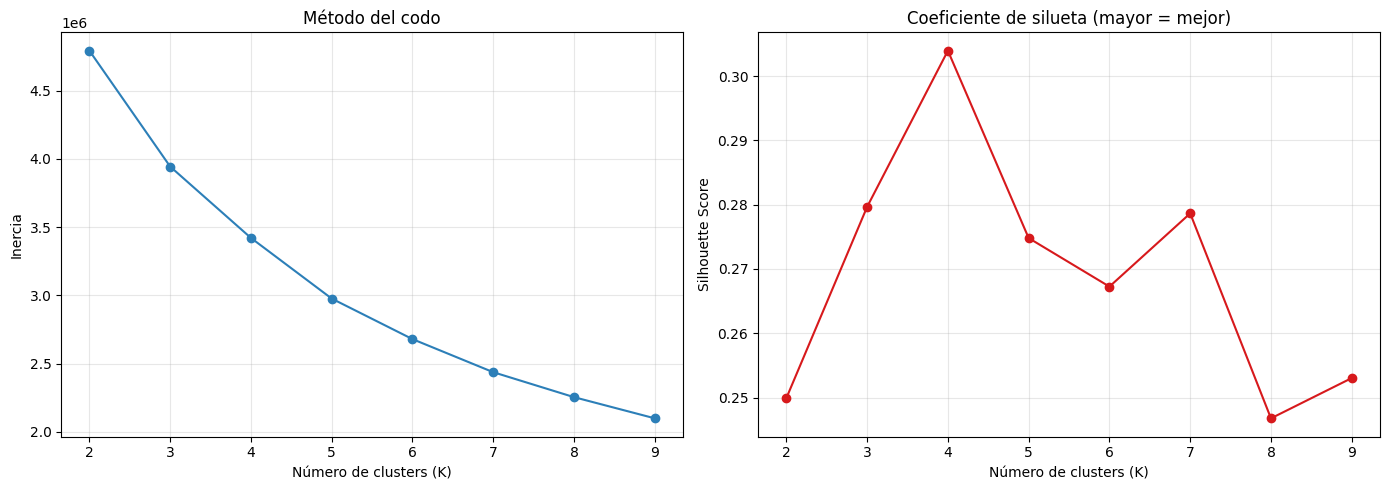

In [7]:
K_range = range(2, 10)
inercias = []
silhouettes = []

# Para silhouette usamos una muestra (es costoso con 35k+ parcelas)
np.random.seed(42)
idx_sample = np.random.choice(
    len(X_cluster_sc),
    size=min(10_000, len(X_cluster_sc)),
    replace=False
)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_sc)
    inercias.append(km.inertia_)
    sil = silhouette_score(X_cluster_sc[idx_sample], labels[idx_sample])
    silhouettes.append(sil)
    print(f"K={k}: inercia={km.inertia_:.0f} | silhouette={sil:.4f}")

# Gráfico doble
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inercias, 'o-', color='#2c7fb8')
axes[0].set_xlabel('Número de clusters (K)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del codo')
axes[0].grid(alpha=0.3)

axes[1].plot(list(K_range), silhouettes, 'o-', color='#d7191c')
axes[1].set_xlabel('Número de clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Coeficiente de silueta (mayor = mejor)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '01_seleccion_k_clusters.png'), dpi=300, bbox_inches='tight')
plt.show()

La curva del codo muestra una disminución gradual de la variabilidad interna a medida que aumenta el número de clusters, sin presentar un punto donde la mejora cambie de forma drástica. Aun así, puede observarse que a partir de K=3 o K=4 las mejoras comienzan a ser cada vez menores. 

El silhouette score muestra que K=3 obtiene el valor más alto (0.2722), seguido muy de cerca por K=7 (0.2673) y K=5 (0.2661). Aunque los valores son moderados, esto es esperable dado que California presenta un gradiente agroclimático continuo más que regiones completamente diferenciadas.

En conjunto, K=3 aparece como la opción más sólida desde el punto de vista estadístico. Sin embargo, K=5 también resulta interesante porque podría generar grupos más fáciles de interpretar desde una perspectiva agronómica, diferenciando regiones como el Valle Central, la costa, las zonas desérticas o las áreas montañosas, siempre que cada grupo mantenga una cantidad suficiente de observaciones para la validación espacial.

Antes de fijar K definitivamente, vale la pena evaluar K=3 y K=5 no solo por la métrica sino por dos criterios prácticos: (1) que cada cluster tenga suficientes condados distintos para hacer el split geográfico train/val/test que elegiste, y (2) que los clusters tengan sentido agronómico al caracterizarlos.

## Comparación K=3 Vs K=5

In [8]:
# Comparar K=3 y K=5: tamaño, nº de condados y perfil por cluster
for k in [3, 5]:
    print(f"\n{'='*60}\n  K = {k}\n{'='*60}")
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_sc)
    df_tmp = df_parcela.with_columns(pl.Series("cluster", labels))

    for c in range(k):
        sub = df_tmp.filter(pl.col("cluster") == c)
        n_parcelas = sub.shape[0]
        n_condados = sub["county"].n_unique()
        # Perfil climático medio del cluster
        tmax_m = sub["tmax"].mean()
        ppt_m  = sub["ppt"].mean()
        print(f"  Cluster {c}: {n_parcelas:>6,} parcelas | "
              f"{n_condados:>2} condados | "
              f"tmax≈{tmax_m:.1f}°C | ppt≈{ppt_m:.0f}mm")


  K = 3
  Cluster 0: 42,342 parcelas |  9 condados | tmax≈31.0°C | ppt≈76mm
  Cluster 1: 358,290 parcelas | 56 condados | tmax≈24.0°C | ppt≈341mm
  Cluster 2: 233,272 parcelas | 55 condados | tmax≈24.4°C | ppt≈274mm

  K = 5
  Cluster 0: 195,672 parcelas | 45 condados | tmax≈25.0°C | ppt≈217mm
  Cluster 1: 210,097 parcelas | 51 condados | tmax≈24.9°C | ppt≈268mm
  Cluster 2: 140,815 parcelas | 53 condados | tmax≈23.7°C | ppt≈532mm
  Cluster 3: 45,954 parcelas | 32 condados | tmax≈18.7°C | ppt≈272mm
  Cluster 4: 41,366 parcelas |  8 condados | tmax≈31.1°C | ppt≈75mm


Aunque K=3 ganaba en silhouette score, al inspeccionar los clusters resultó demasiado grueso. Con K=3, el desierto quedaba bien aislado (cluster de tmax ≈ 31°C y ppt ≈ 77mm, 9 condados), pero los otros dos clusters eran esencialmente dos mitades del valle con perfiles climáticos casi idénticos (tmax 24.0 vs 24.4°C, ppt 342 vs 274mm). Es decir, K=3 distinguía el desierto pero no separaba costa, valle y montaña.
Con K=5, en cambio, la segmentación adquirió un sentido agronómico mucho más claro y cada cluster mantuvo condados suficientes para el split geográfico. 

## Clusterin con K=3

In [9]:
K3 = 3
kmeans_final = KMeans(n_clusters=K3, random_state=SEED, n_init=10)
labels_raw = kmeans_final.fit_predict(X_cluster_sc)

# ── Reordenar clusters por tmax media (criterio fijo y reproducible) ──
df_tmp = df_parcela.with_columns(pl.Series("cluster_raw", labels_raw))
orden = (
    df_tmp.group_by("cluster_raw")
    .agg(pl.col("tmax").mean().alias("tmax_medio"))
    .sort("tmax_medio")               # de más frío a más cálido
    .with_row_index("cluster_nuevo")  # 0=más frío ... 4=más cálido
)
mapa_reorden = dict(zip(orden["cluster_raw"], orden["cluster_nuevo"]))

df_parcela = df_tmp.with_columns(
    pl.col("cluster_raw").replace(mapa_reorden).alias("cluster")
).drop("cluster_raw")


# Mostrar el reordenamiento aplicado
print("Reordenamiento aplicado (por tmax creciente):")
print(orden)

# ── Caracterización completa de cada cluster ──
perfil_clusters = (
    df_parcela
    .group_by("cluster")
    .agg([
        pl.len().alias("n_parcelas"),
        pl.col("county").n_unique().alias("n_condados"),
        pl.col("tmax").mean().round(1).alias("tmax"),
        pl.col("tmin").mean().round(1).alias("tmin"),
        pl.col("ppt").mean().round(0).alias("ppt"),
        pl.col("vpdmean").mean().round(1).alias("vpdmean"),
        pl.col("claytotal_r").mean().round(1).alias("clay"),
        pl.col("sandtotal_r").mean().round(1).alias("sand"),
        pl.col("ph1to1h2o_r").mean().round(2).alias("ph"),
    ])
    .sort("cluster")
)


Reordenamiento aplicado (por tmax creciente):
shape: (3, 3)
┌───────────────┬─────────────┬────────────┐
│ cluster_nuevo ┆ cluster_raw ┆ tmax_medio │
│ ---           ┆ ---         ┆ ---        │
│ u32           ┆ i32         ┆ f64        │
╞═══════════════╪═════════════╪════════════╡
│ 0             ┆ 1           ┆ 23.959916  │
│ 1             ┆ 2           ┆ 24.430592  │
│ 2             ┆ 0           ┆ 31.019615  │
└───────────────┴─────────────┴────────────┘


In [10]:
pl.Config.set_tbl_cols(-1)   # mostrar todas las columnas sin omitir

print(perfil_clusters)

shape: (3, 10)
┌─────────┬────────────┬────────────┬──────┬──────┬───────┬─────────┬──────┬──────┬──────┐
│ cluster ┆ n_parcelas ┆ n_condados ┆ tmax ┆ tmin ┆ ppt   ┆ vpdmean ┆ clay ┆ sand ┆ ph   │
│ ---     ┆ ---        ┆ ---        ┆ ---  ┆ ---  ┆ ---   ┆ ---     ┆ ---  ┆ ---  ┆ ---  │
│ i32     ┆ u32        ┆ u32        ┆ f64  ┆ f64  ┆ f64   ┆ f64     ┆ f64  ┆ f64  ┆ f64  │
╞═════════╪════════════╪════════════╪══════╪══════╪═══════╪═════════╪══════╪══════╪══════╡
│ 0       ┆ 358290     ┆ 56         ┆ 24.0 ┆ 8.8  ┆ 341.0 ┆ 12.9    ┆ 33.0 ┆ 27.5 ┆ 7.3  │
│ 1       ┆ 233272     ┆ 55         ┆ 24.4 ┆ 9.3  ┆ 274.0 ┆ 13.5    ┆ 12.1 ┆ 68.7 ┆ 7.31 │
│ 2       ┆ 42342      ┆ 9          ┆ 31.0 ┆ 15.0 ┆ 76.0  ┆ 23.5    ┆ 29.0 ┆ 30.6 ┆ 8.26 │
└─────────┴────────────┴────────────┴──────┴──────┴───────┴─────────┴──────┴──────┴──────┘


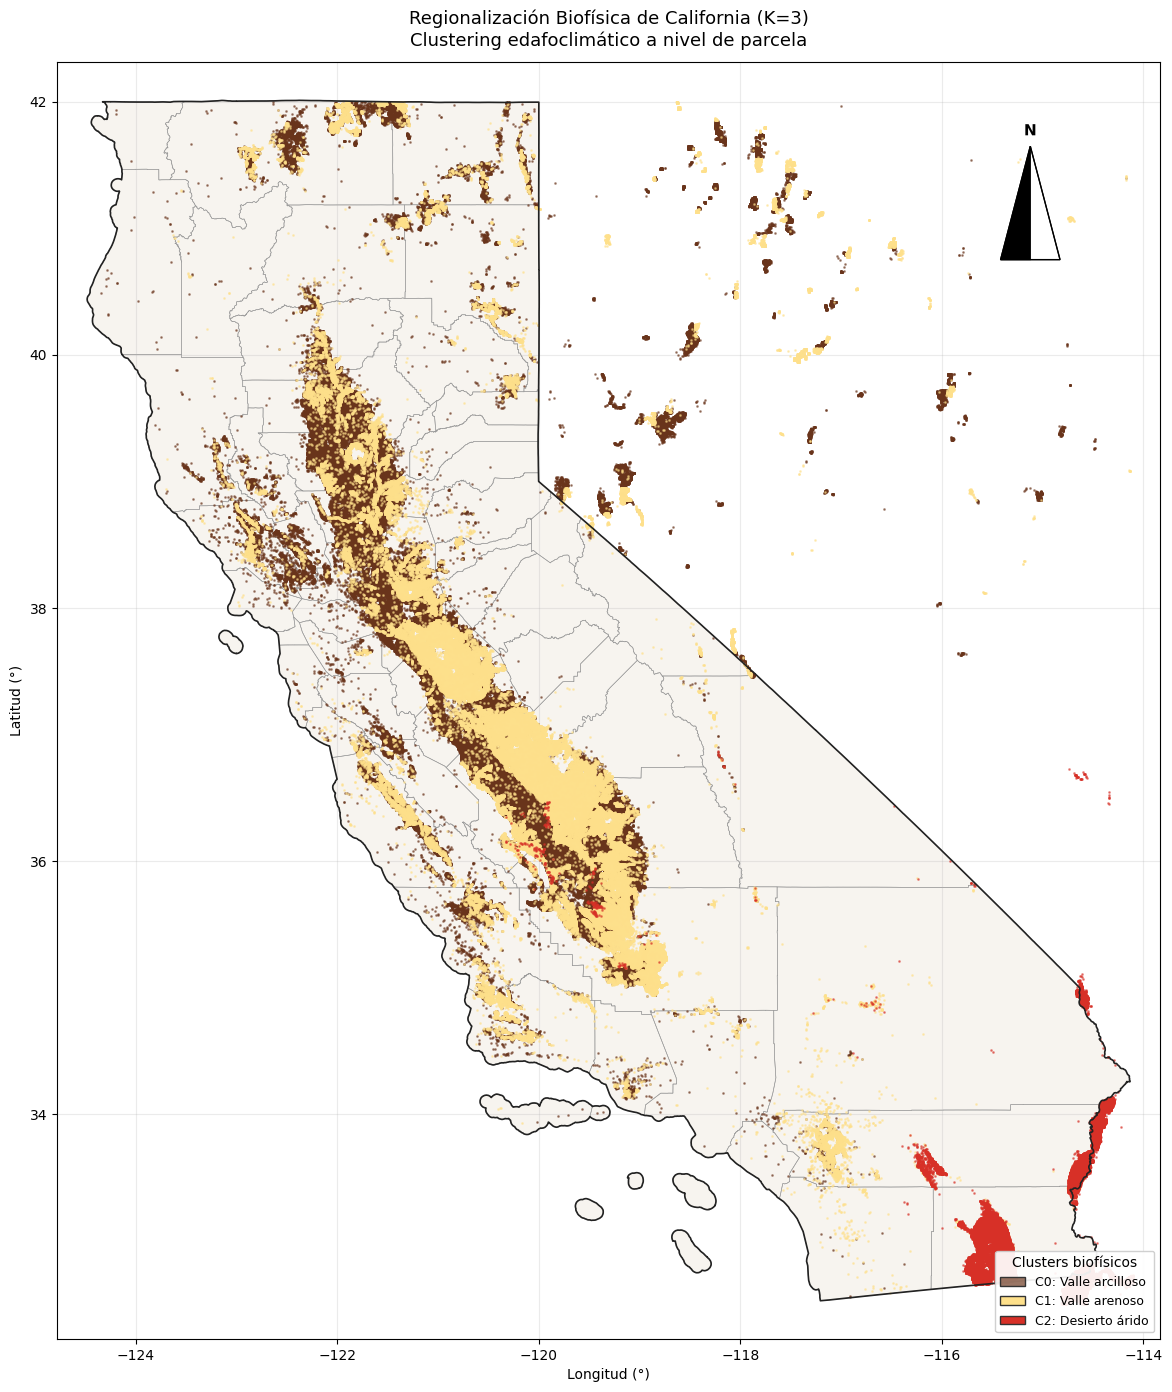

In [11]:
# Etiquetas agronómicas definitivas
etiquetas_cluster = {
    0: "Valle arcilloso",         
    1: "Valle arenoso",          
    2: "Desierto árido",  
   
}

# Colores por cluster (coherentes con el perfil)
colores_cluster = {
    0: "#69341bac",  # naranja terroso - valle arcilloso
    1: '#fee08b',  # amarillo arena - valle arenoso
    #2: '#91cf60',  # verde - zona húmeda
   # 3: '#4575b4',  # azul - montaña/frío
    2: '#d73027'   # rojo - desierto
}
# Preparar puntos
df_mapa = df_parcela.select(["lon", "lat", "cluster"]).to_pandas()

fig, ax = plt.subplots(figsize=(12, 14))

# Fondo: contorno de California
gdf_counties_fixed = gdf_counties.copy()
gdf_counties_fixed['geometry'] = gdf_counties_fixed.geometry.buffer(0)
california = gdf_counties_fixed.unary_union
gdf_ca = gpd.GeoDataFrame(geometry=[california], crs=gdf_counties.crs)
gdf_ca.plot(ax=ax, facecolor='#f7f4ef', edgecolor='none', zorder=0)

# Bordes de condados
gdf_counties.boundary.plot(ax=ax, edgecolor='#999999', linewidth=0.4, zorder=1)

# Puntos por cluster
for c in range(K3):
    mask = df_mapa['cluster'] == c
    ax.scatter(
        df_mapa.loc[mask, 'lon'],
        df_mapa.loc[mask, 'lat'],
        c=colores_cluster[c], s=1.0, alpha=0.5,
        label=f"C{c}: {etiquetas_cluster[c]}",
        zorder=3, rasterized=True
    )

# Borde exterior del estado
gdf_ca.boundary.plot(ax=ax, edgecolor='#222222', linewidth=1.2, zorder=4)

# Leyenda
legend_elements = [
    Patch(facecolor=colores_cluster[c], edgecolor='#333',
          label=f"C{c}: {etiquetas_cluster[c]}")
    for c in range(K3)
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9,
          title='Clusters biofísicos', framealpha=0.92)

ax.set_title(
    'Regionalización Biofísica de California (K=3)\nClustering edafoclimático a nivel de parcela',
    fontsize=13, pad=12
)
ax.set_xlabel('Longitud (°)', fontsize=10)
ax.set_ylabel('Latitud (°)', fontsize=10)
ax.grid(True, alpha=0.25)

minx, miny, maxx, maxy = gdf_counties.total_bounds
ax.set_xlim(minx - 0.3, maxx + 0.3)
ax.set_ylim(miny - 0.3, maxy + 0.3)

agregar_norte(ax, x=0.96, y=0.97)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '02_k3_mapa_clusters_biofisicos.png'), dpi=300, bbox_inches='tight')
plt.show()


In [12]:
# Unir la asignación de cluster al dataframe completo
cluster_map = df_parcela.select(["lon", "lat", "cluster"])
df_k3 = df.join(cluster_map, on=["lon", "lat"], how="left")

n_sin_cluster = df_k3.filter(pl.col("cluster").is_null()).shape[0]
print(f"Filas sin cluster asignado: {n_sin_cluster}")

# ── Guardar dataset y objetos con nombre que indique K=3 ──
RUTA_DATOS = '../Data/'
MODELS_DIR = '../models/'
os.makedirs(MODELS_DIR, exist_ok=True)

df_k3.write_parquet(os.path.join(RUTA_DATOS, "df_cluster_k3.parquet"))
joblib.dump(scaler_cluster, os.path.join(MODELS_DIR, "scaler_cluster_k3.pkl"))
joblib.dump(kmeans_final,   os.path.join(MODELS_DIR, "kmeans_clusters_k3.pkl"))
print("Guardado: df_cluster_k3.parquet + modelos K=3")

Filas sin cluster asignado: 0
Guardado: df_cluster_k3.parquet + modelos K=3


### Comparación con otros modelos

In [13]:
K = 3

# Una única muestra representativa para comparar TODOS los algoritmos
np.random.seed(42)
N = 30_000
idx = np.random.choice(X_cluster_sc.shape[0], size=N, replace=False)
X_s = X_cluster_sc[idx]
print(f"Muestra de comparación: {X_s.shape[0]:,} parcelas")

def evaluar(nombre, labels, X):
    """Calcula las tres métricas internas de calidad del agrupamiento."""
    return {
        "algoritmo": nombre,
        "silhouette": round(silhouette_score(X, labels), 4),
        "calinski_harabasz": round(calinski_harabasz_score(X, labels), 1),
        "davies_bouldin": round(davies_bouldin_score(X, labels), 4),
    }

resultados = []


Muestra de comparación: 30,000 parcelas


In [14]:
# K-Means...
resultados.append(evaluar("K-Means",
    KMeans(n_clusters=K, random_state=42, n_init=10).fit_predict(X_s), X_s))

# MiniBatch K-Means...
resultados.append(evaluar("MiniBatch K-Means",
    MiniBatchKMeans(n_clusters=K, random_state=42, n_init=10, batch_size=5_000).fit_predict(X_s), X_s))

# Gaussian Mixture...
resultados.append(evaluar("Gaussian Mixture",
    GaussianMixture(n_components=K, random_state=42, n_init=3).fit_predict(X_s), X_s))

# Jerárquico (Ward)...
resultados.append(evaluar("Jerárquico (Ward)",
    AgglomerativeClustering(n_clusters=K, linkage="ward").fit_predict(X_s), X_s))


In [15]:
# --- Tabla comparativa ---
df_comp = pl.DataFrame(resultados)
print("="*60)
print("COMPARACIÓN DE ALGORITMOS (K=3, muestra de 30.000 parcelas)")
print("="*60)
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print(df_comp)

# --- Lectura automática ---
print()
mejor_sil = max(resultados, key=lambda r: r["silhouette"])
mejor_ch  = max(resultados, key=lambda r: r["calinski_harabasz"])
mejor_db  = min(resultados, key=lambda r: r["davies_bouldin"])   # menor es mejor
print(f"Mejor Silhouette (mayor=mejor):        {mejor_sil['algoritmo']} ({mejor_sil['silhouette']})")
print(f"Mejor Calinski-Harabasz (mayor=mejor): {mejor_ch['algoritmo']} ({mejor_ch['calinski_harabasz']})")
print(f"Mejor Davies-Bouldin (menor=mejor):    {mejor_db['algoritmo']} ({mejor_db['davies_bouldin']})")
print()


COMPARACIÓN DE ALGORITMOS (K=3, muestra de 30.000 parcelas)
shape: (4, 4)
┌───────────────────┬────────────┬───────────────────┬────────────────┐
│ algoritmo         ┆ silhouette ┆ calinski_harabasz ┆ davies_bouldin │
│ ---               ┆ ---        ┆ ---               ┆ ---            │
│ str               ┆ f64        ┆ f64               ┆ f64            │
╞═══════════════════╪════════════╪═══════════════════╪════════════════╡
│ K-Means           ┆ 0.2809     ┆ 9054.2            ┆ 1.2446         │
│ MiniBatch K-Means ┆ 0.1632     ┆ 5628.3            ┆ 2.1445         │
│ Gaussian Mixture  ┆ 0.1929     ┆ 4535.5            ┆ 1.9329         │
│ Jerárquico (Ward) ┆ 0.2649     ┆ 8573.0            ┆ 1.2339         │
└───────────────────┴────────────┴───────────────────┴────────────────┘

Mejor Silhouette (mayor=mejor):        K-Means (0.2809)
Mejor Calinski-Harabasz (mayor=mejor): K-Means (9054.2)
Mejor Davies-Bouldin (menor=mejor):    Jerárquico (Ward) (1.2339)



## Validación cluster K=3

### Validación interna

In [16]:
# Buscar el array de asignaciones por parcela
for nombre, valor in list(globals().items()):
    try:
        if hasattr(valor, '__len__') and len(valor) == len(X_cluster_sc):
            import numpy as np
            arr = np.asarray(valor)
            if arr.dtype.kind in 'iu' and arr.min() >= 0 and arr.max() <= 2:
                print(f"Candidato: '{nombre}' (len={len(valor)}, valores únicos={np.unique(arr)})")
    except Exception:
        pass

Candidato: 'labels_raw' (len=633904, valores únicos=[0 1 2])


In [17]:
# Las etiquetas deben venir del MISMO objeto que generó X_cluster_sc: df_parcela
labels_validacion = df_parcela["cluster"].to_numpy()

# Verificar dimensiones y correspondencia
print("X shape:", X_cluster_sc.shape)
print("labels shape:", labels_validacion.shape)
print("clusters únicos:", np.unique(labels_validacion))

# Muestra para eficiencia (silhouette es costoso)
np.random.seed(42)
idx = np.random.choice(len(X_cluster_sc), size=min(10_000, len(X_cluster_sc)), replace=False)

sil = silhouette_score(X_cluster_sc[idx], labels_validacion[idx])
ch  = calinski_harabasz_score(X_cluster_sc, labels_validacion)
db  = davies_bouldin_score(X_cluster_sc, labels_validacion)

print(f"\nSilhouette: {sil:.4f}")
print(f"Calinski-Harabasz: {ch:.1f}")
print(f"Davies-Bouldin: {db:.4f}")

X shape: (633904, 10)
labels shape: (633904,)
clusters únicos: [0 1 2]

Silhouette: 0.2797
Calinski-Harabasz: 192432.0
Davies-Bouldin: 1.2396


### Validación: **Estabilidad del clustering**

In [18]:
# Entrenar con varias semillas y comparar consistencia
labels_semillas = []
for seed in [0, 1, 42, 123, 2024]:
    km = KMeans(n_clusters=3, random_state=seed, n_init=10)
    labels_semillas.append(km.fit_predict(X_cluster_sc))

print("Estabilidad entre semillas (Adjusted Rand Index):")
print("(1.0 = particiones idénticas, 0 = aleatorias)\n")
aris = []
for i in range(len(labels_semillas)):
    for j in range(i+1, len(labels_semillas)):
        ari = adjusted_rand_score(labels_semillas[i], labels_semillas[j])
        aris.append(ari)
        print(f"  Semilla {i} vs {j}: ARI = {ari:.4f}")
print(f"\n  ARI medio: {np.mean(aris):.4f}")

Estabilidad entre semillas (Adjusted Rand Index):
(1.0 = particiones idénticas, 0 = aleatorias)

  Semilla 0 vs 1: ARI = 0.9999
  Semilla 0 vs 2: ARI = 0.9999
  Semilla 0 vs 3: ARI = 0.9999
  Semilla 0 vs 4: ARI = 0.9999
  Semilla 1 vs 2: ARI = 1.0000
  Semilla 1 vs 3: ARI = 1.0000
  Semilla 1 vs 4: ARI = 1.0000
  Semilla 2 vs 3: ARI = 0.9999
  Semilla 2 vs 4: ARI = 1.0000
  Semilla 3 vs 4: ARI = 1.0000

  ARI medio: 0.9999


**Validación agronómica**

In [19]:
# Distribución de cultivos por cluster
dist_cultivo_cluster = (
    df_k3
    .group_by(["cluster", "crop_name"])
    .len()
    .sort(["cluster", "len"], descending=[False, True])
)

# Top 3 cultivos por cluster
for c in range(3):
    print(f"\nCluster {c} ({etiquetas_cluster[c]}) — cultivos principales:")
    top = dist_cultivo_cluster.filter(pl.col("cluster") == c).head(3)
    print(top)


Cluster 0 (Valle arcilloso) — cultivos principales:
shape: (3, 3)
┌─────────┬───────────┬───────┐
│ cluster ┆ crop_name ┆ len   │
│ ---     ┆ ---       ┆ ---   │
│ i32     ┆ str       ┆ u32   │
╞═════════╪═══════════╪═══════╡
│ 0       ┆ Alfalfa   ┆ 70149 │
│ 0       ┆ Almonds   ┆ 62004 │
│ 0       ┆ Rice      ┆ 48476 │
└─────────┴───────────┴───────┘

Cluster 1 (Valle arenoso) — cultivos principales:
shape: (3, 3)
┌─────────┬───────────┬───────┐
│ cluster ┆ crop_name ┆ len   │
│ ---     ┆ ---       ┆ ---   │
│ i32     ┆ str       ┆ u32   │
╞═════════╪═══════════╪═══════╡
│ 1       ┆ Almonds   ┆ 74089 │
│ 1       ┆ Grapes    ┆ 49493 │
│ 1       ┆ Alfalfa   ┆ 37919 │
└─────────┴───────────┴───────┘

Cluster 2 (Desierto árido) — cultivos principales:
shape: (3, 3)
┌─────────┬───────────┬───────┐
│ cluster ┆ crop_name ┆ len   │
│ ---     ┆ ---       ┆ ---   │
│ i32     ┆ str       ┆ u32   │
╞═════════╪═══════════╪═══════╡
│ 2       ┆ Alfalfa   ┆ 28257 │
│ 2       ┆ Wheat     ┆ 7074  │
│ 

 **Especialización relativa**
 Qué cultivos están sobrerrepresentados en cada cluster respecto a su frecuencia global.

In [20]:
# Frecuencia global de cada cultivo
total_global = df_k3.shape[0]
freq_global = (
    df_k3.group_by("crop_name")
    .len()
    .with_columns((pl.col("len") / total_global).alias("prop_global"))
    .select(["crop_name", "prop_global"])
)

# Frecuencia de cada cultivo dentro de cada cluster
freq_cluster = (
    df_k3.group_by(["cluster", "crop_name"])
    .len()
    .join(
        df_k3.group_by("cluster").len().rename({"len": "total_cluster"}),
        on="cluster"
    )
    .with_columns((pl.col("len") / pl.col("total_cluster")).alias("prop_cluster"))
)

# Ratio de especialización = prop_cluster / prop_global
# >1 significa sobrerrepresentado en ese cluster
especializacion = (
    freq_cluster
    .join(freq_global, on="crop_name")
    .with_columns(
        (pl.col("prop_cluster") / pl.col("prop_global")).alias("ratio_espec")
    )
    .sort(["cluster", "ratio_espec"], descending=[False, True])
)

# Top 3 cultivos MÁS característicos (sobrerrepresentados) por cluster
for c in range(3):
    print(f"\nCluster {c} ({etiquetas_cluster[c]}) — cultivos característicos:")
    top = (
        especializacion
        .filter(pl.col("cluster") == c)
        .filter(pl.col("len") >= 100)  # mínimo de observaciones
        .head(3)
        .select(["crop_name", "ratio_espec", "len"])
    )
    print(top)


Cluster 0 (Valle arcilloso) — cultivos característicos:
shape: (3, 3)
┌───────────┬─────────────┬───────┐
│ crop_name ┆ ratio_espec ┆ len   │
│ ---       ┆ ---         ┆ ---   │
│ str       ┆ f64         ┆ u32   │
╞═══════════╪═════════════╪═══════╡
│ Rice      ┆ 1.666364    ┆ 48476 │
│ Tomatoes  ┆ 1.504321    ┆ 22429 │
│ Cotton    ┆ 1.295462    ┆ 19129 │
└───────────┴─────────────┴───────┘

Cluster 1 (Valle arenoso) — cultivos característicos:
shape: (3, 3)
┌──────────────┬─────────────┬───────┐
│ crop_name    ┆ ratio_espec ┆ len   │
│ ---          ┆ ---         ┆ ---   │
│ str          ┆ f64         ┆ u32   │
╞══════════════╪═════════════╪═══════╡
│ Grapes       ┆ 1.61909     ┆ 49493 │
│ Strawberries ┆ 1.515968    ┆ 1181  │
│ Almonds      ┆ 1.478226    ┆ 74089 │
└──────────────┴─────────────┴───────┘

Cluster 2 (Desierto árido) — cultivos característicos:
shape: (3, 3)
┌───────────┬─────────────┬───────┐
│ crop_name ┆ ratio_espec ┆ len   │
│ ---       ┆ ---         ┆ ---   │
│ str  

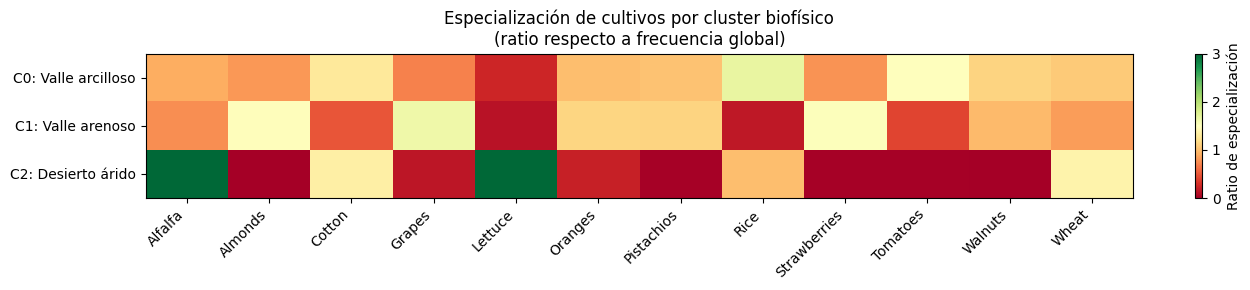

In [21]:
# Gráfico de ratio 

cultivos_unicos = sorted(df_k3["crop_name"].unique().to_list())

matriz_espec = np.ones((3, len(cultivos_unicos)))
for fila in especializacion.iter_rows(named=True):
    c = fila["cluster"]
    j = cultivos_unicos.index(fila["crop_name"])
    matriz_espec[c, j] = fila["ratio_espec"]

fig, ax = plt.subplots(figsize=(14, 3))
im = ax.imshow(matriz_espec, cmap='RdYlGn', aspect='auto',
               vmin=0, vmax=3)
plt.colorbar(im, ax=ax, label='Ratio de especialización')
ax.set_xticks(range(len(cultivos_unicos)))
ax.set_xticklabels(cultivos_unicos, rotation=45, ha='right')
ax.set_yticks(range(3))
ax.set_yticklabels([f"C{c}: {etiquetas_cluster[c]}" for c in range(3)])
ax.set_title('Especialización de cultivos por cluster biofísico\n(ratio respecto a frecuencia global)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '03_especializacion_cultivos.png'), dpi=300, bbox_inches='tight')
plt.show()

**Validación de separación entre clusters**

C:\Users\lesli\AppData\Local\Temp\ipykernel_23500\1480367119.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos_por_cluster, labels=[f"C{c}" for c in range(3)])
C:\Users\lesli\AppData\Local\Temp\ipykernel_23500\1480367119.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos_por_cluster, labels=[f"C{c}" for c in range(3)])
C:\Users\lesli\AppData\Local\Temp\ipykernel_23500\1480367119.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos_por_cluster, labels=[f"C{c}" for c in range(3)])
C:\Users\lesli\AppData\Local\Temp\ipykernel_23500\1480367119.py:7: MatplotlibDeprecation

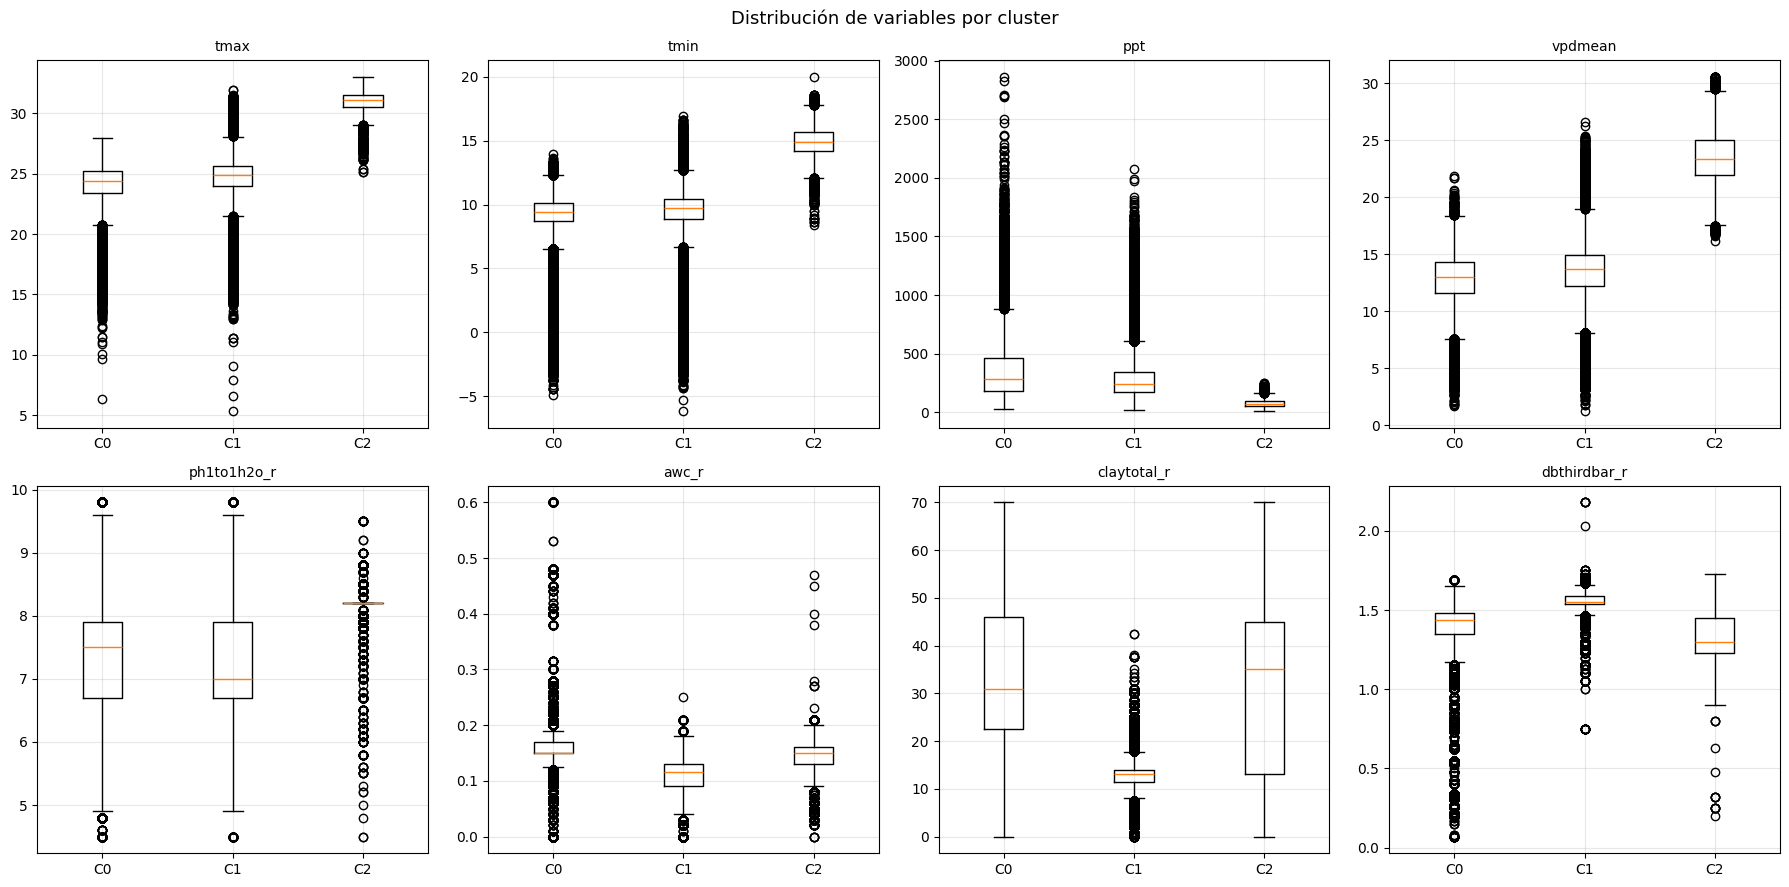

In [22]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, var in zip(axes.ravel(), vars_cluster):
    datos_por_cluster = [
        df_parcela.filter(pl.col("cluster") == c)[var].to_numpy()
        for c in range(3)
    ]
    ax.boxplot(datos_por_cluster, labels=[f"C{c}" for c in range(3)])
    ax.set_title(var, fontsize=10)
    ax.grid(alpha=0.3)
plt.suptitle("Distribución de variables por cluster", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '04_boxplots_clusters.png'), dpi=200, bbox_inches='tight')
plt.show()

## Clustering con K= 5

In [23]:
km5 = KMeans(n_clusters=5, random_state=42, n_init=10)
labels5 = km5.fit_predict(X_cluster_sc)
df_parcela = df_parcela.with_columns(pl.Series("cluster", labels5))

# Condados por cluster
for c in range(5):
    sub = df_parcela.filter(pl.col("cluster") == c)
    condados = sub.group_by("county").len().sort("len", descending=True)
    print(f"\n{'='*50}")
    print(f"Cluster {c}: {sub.shape[0]:,} parcelas, {sub['county'].n_unique()} condados")
    print(f"  tmax≈{sub['tmax'].mean():.1f}°C | ppt≈{sub['ppt'].mean():.0f}mm")
    print(f"  Condados principales:")
    print(condados.head(10))


Cluster 0: 195,672 parcelas, 45 condados
  tmax≈25.0°C | ppt≈217mm
  Condados principales:
shape: (10, 2)
┌─────────────┬───────┐
│ county      ┆ len   │
│ ---         ┆ ---   │
│ str         ┆ u32   │
╞═════════════╪═══════╡
│ Fresno      ┆ 44853 │
│ Tulare      ┆ 28081 │
│ Kern        ┆ 27338 │
│ Kings       ┆ 21601 │
│ Merced      ┆ 21008 │
│ Colusa      ┆ 8481  │
│ San Joaquin ┆ 7901  │
│ Stanislaus  ┆ 5637  │
│ Glenn       ┆ 4836  │
│ Sutter      ┆ 4697  │
└─────────────┴───────┘

Cluster 1: 210,097 parcelas, 51 condados
  tmax≈24.9°C | ppt≈268mm
  Condados principales:
shape: (10, 2)
┌─────────────┬───────┐
│ county      ┆ len   │
│ ---         ┆ ---   │
│ str         ┆ u32   │
╞═════════════╪═══════╡
│ Fresno      ┆ 42359 │
│ Kern        ┆ 32884 │
│ Madera      ┆ 26656 │
│ Tulare      ┆ 18537 │
│ Stanislaus  ┆ 17472 │
│ Merced      ┆ 15465 │
│ San Joaquin ┆ 14376 │
│ Kings       ┆ 13541 │
│ Riverside   ┆ 4082  │
│ Sutter      ┆ 2970  │
└─────────────┴───────┘

Cluster 2: 140,81

Como el clustering se realizó sobre parcelas individuales, no es extraño que un mismo condado aparezca en varios clusters. Esto ocurre especialmente en condados grandes, donde existen diferencias importantes de clima y suelo entre distintas zonas. En lugar de ser un error, esta situación confirma que los clusters están capturando características edafoclimáticas de las parcelas y no simplemente una división administrativa del territorio. Por esta razón, el split train/validation/test se realizará por separado dentro de cada cluster. De esta forma, cada modelo se entrena y evalúa únicamente sobre el régimen agroclimático que representa, manteniendo la validación espacial y evitando que las regiones dominantes condicionen el desempeño de los demás modelos.

In [24]:
print("X_cluster_sc:", X_cluster_sc.shape)   # requiere haber ejecutado la celda que lo crea

K = 5

# Una única muestra representativa para comparar TODOS los algoritmos
np.random.seed(42)
N = 30_000
idx = np.random.choice(X_cluster_sc.shape[0], size=N, replace=False)
X_s = X_cluster_sc[idx]
print(f"Muestra de comparación: {X_s.shape[0]:,} parcelas")

X_cluster_sc: (633904, 10)
Muestra de comparación: 30,000 parcelas


In [25]:
def evaluar(nombre, labels, X):
    """Calcula las tres métricas internas de calidad del agrupamiento."""
    return {
        "algoritmo": nombre,
        "silhouette": round(silhouette_score(X, labels), 4),
        "calinski_harabasz": round(calinski_harabasz_score(X, labels), 1),
        "davies_bouldin": round(davies_bouldin_score(X, labels), 4),
    }

resultados = []


In [26]:
# K-Means...
resultados.append(evaluar("K-Means",
    KMeans(n_clusters=K, random_state=42, n_init=10).fit_predict(X_s), X_s))

In [27]:
# MiniBatch K-Means...
resultados.append(evaluar("MiniBatch K-Means",
    MiniBatchKMeans(n_clusters=K, random_state=42, n_init=10, batch_size=5_000).fit_predict(X_s), X_s))


In [28]:
# Gaussian Mixture...
resultados.append(evaluar("Gaussian Mixture",
    GaussianMixture(n_components=K, random_state=42, n_init=3).fit_predict(X_s), X_s))


In [29]:
# Jerárquico (Ward)...
resultados.append(evaluar("Jerárquico (Ward)",
    AgglomerativeClustering(n_clusters=K, linkage="ward").fit_predict(X_s), X_s))

In [30]:
# --- Tabla comparativa ---
df_comp = pl.DataFrame(resultados)
print("="*60)
print("COMPARACIÓN DE ALGORITMOS (K=5, muestra de 30.000 parcelas)")
print("="*60)
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print(df_comp)

# --- Lectura automática ---
print()
mejor_sil = max(resultados, key=lambda r: r["silhouette"])
mejor_ch  = max(resultados, key=lambda r: r["calinski_harabasz"])
mejor_db  = min(resultados, key=lambda r: r["davies_bouldin"])   # menor es mejor
print(f"Mejor Silhouette (mayor=mejor):        {mejor_sil['algoritmo']} ({mejor_sil['silhouette']})")
print(f"Mejor Calinski-Harabasz (mayor=mejor): {mejor_ch['algoritmo']} ({mejor_ch['calinski_harabasz']})")
print(f"Mejor Davies-Bouldin (menor=mejor):    {mejor_db['algoritmo']} ({mejor_db['davies_bouldin']})")
print()


COMPARACIÓN DE ALGORITMOS (K=5, muestra de 30.000 parcelas)
shape: (4, 4)
┌───────────────────┬────────────┬───────────────────┬────────────────┐
│ algoritmo         ┆ silhouette ┆ calinski_harabasz ┆ davies_bouldin │
│ ---               ┆ ---        ┆ ---               ┆ ---            │
│ str               ┆ f64        ┆ f64               ┆ f64            │
╞═══════════════════╪════════════╪═══════════════════╪════════════════╡
│ K-Means           ┆ 0.2791     ┆ 8521.8            ┆ 1.3649         │
│ MiniBatch K-Means ┆ 0.2202     ┆ 6980.2            ┆ 1.5902         │
│ Gaussian Mixture  ┆ 0.2475     ┆ 5372.9            ┆ 2.0612         │
│ Jerárquico (Ward) ┆ 0.2796     ┆ 7986.2            ┆ 1.3893         │
└───────────────────┴────────────┴───────────────────┴────────────────┘

Mejor Silhouette (mayor=mejor):        Jerárquico (Ward) (0.2796)
Mejor Calinski-Harabasz (mayor=mejor): K-Means (8521.8)
Mejor Davies-Bouldin (menor=mejor):    K-Means (1.3649)



#### Estimación final del cluster

In [31]:
K_FINAL = 5
kmeans_final = KMeans(n_clusters=K_FINAL, random_state=SEED, n_init=10)
labels_raw = kmeans_final.fit_predict(X_cluster_sc)

# ── Reordenar clusters por tmax media (criterio fijo y reproducible) ──
df_tmp = df_parcela.with_columns(pl.Series("cluster_raw", labels_raw))
orden = (
    df_tmp.group_by("cluster_raw")
    .agg(pl.col("tmax").mean().alias("tmax_medio"))
    .sort("tmax_medio")               # de más frío a más cálido
    .with_row_index("cluster_nuevo")  # 0=más frío ... 4=más cálido
)
mapa_reorden = dict(zip(orden["cluster_raw"], orden["cluster_nuevo"]))

df_parcela = df_tmp.with_columns(
    pl.col("cluster_raw").replace(mapa_reorden).alias("cluster")
).drop("cluster_raw")


# Mostrar el reordenamiento aplicado
print("Reordenamiento aplicado (por tmax creciente):")
print(orden)

# ── Caracterización completa de cada cluster ──
perfil_clusters = (
    df_parcela
    .group_by("cluster")
    .agg([
        pl.len().alias("n_parcelas"),
        pl.col("county").n_unique().alias("n_condados"),
        pl.col("tmax").mean().round(1).alias("tmax"),
        pl.col("tmin").mean().round(1).alias("tmin"),
        pl.col("ppt").mean().round(0).alias("ppt"),
        pl.col("vpdmean").mean().round(1).alias("vpdmean"),
        pl.col("claytotal_r").mean().round(1).alias("clay"),
        pl.col("sandtotal_r").mean().round(1).alias("sand"),
        pl.col("ph1to1h2o_r").mean().round(2).alias("ph"),
    ])
    .sort("cluster")
)


Reordenamiento aplicado (por tmax creciente):
shape: (5, 3)
┌───────────────┬─────────────┬────────────┐
│ cluster_nuevo ┆ cluster_raw ┆ tmax_medio │
│ ---           ┆ ---         ┆ ---        │
│ u32           ┆ i32         ┆ f64        │
╞═══════════════╪═════════════╪════════════╡
│ 0             ┆ 3           ┆ 18.676282  │
│ 1             ┆ 2           ┆ 23.667516  │
│ 2             ┆ 1           ┆ 24.852929  │
│ 3             ┆ 0           ┆ 25.042208  │
│ 4             ┆ 4           ┆ 31.05033   │
└───────────────┴─────────────┴────────────┘


In [32]:
pl.Config.set_tbl_cols(-1)   # mostrar todas las columnas sin omitir

print(perfil_clusters)

shape: (5, 10)
┌─────────┬────────────┬────────────┬──────┬──────┬───────┬─────────┬──────┬──────┬──────┐
│ cluster ┆ n_parcelas ┆ n_condados ┆ tmax ┆ tmin ┆ ppt   ┆ vpdmean ┆ clay ┆ sand ┆ ph   │
│ ---     ┆ ---        ┆ ---        ┆ ---  ┆ ---  ┆ ---   ┆ ---     ┆ ---  ┆ ---  ┆ ---  │
│ i32     ┆ u32        ┆ u32        ┆ f64  ┆ f64  ┆ f64   ┆ f64     ┆ f64  ┆ f64  ┆ f64  │
╞═════════╪════════════╪════════════╪══════╪══════╪═══════╪═════════╪══════╪══════╪══════╡
│ 0       ┆ 45954      ┆ 32         ┆ 18.7 ┆ 1.7  ┆ 272.0 ┆ 11.2    ┆ 22.4 ┆ 43.0 ┆ 7.34 │
│ 1       ┆ 140815     ┆ 53         ┆ 23.7 ┆ 9.3  ┆ 532.0 ┆ 11.7    ┆ 32.6 ┆ 25.8 ┆ 6.65 │
│ 2       ┆ 210097     ┆ 51         ┆ 24.9 ┆ 9.8  ┆ 268.0 ┆ 13.7    ┆ 11.8 ┆ 69.8 ┆ 7.3  │
│ 3       ┆ 195672     ┆ 45         ┆ 25.0 ┆ 9.7  ┆ 217.0 ┆ 14.1    ┆ 33.4 ┆ 28.9 ┆ 7.78 │
│ 4       ┆ 41366      ┆ 8          ┆ 31.1 ┆ 15.0 ┆ 75.0  ┆ 23.6    ┆ 29.5 ┆ 29.6 ┆ 8.26 │
└─────────┴────────────┴────────────┴──────┴──────┴───────┴─────────┴──────

# Mapear resultados


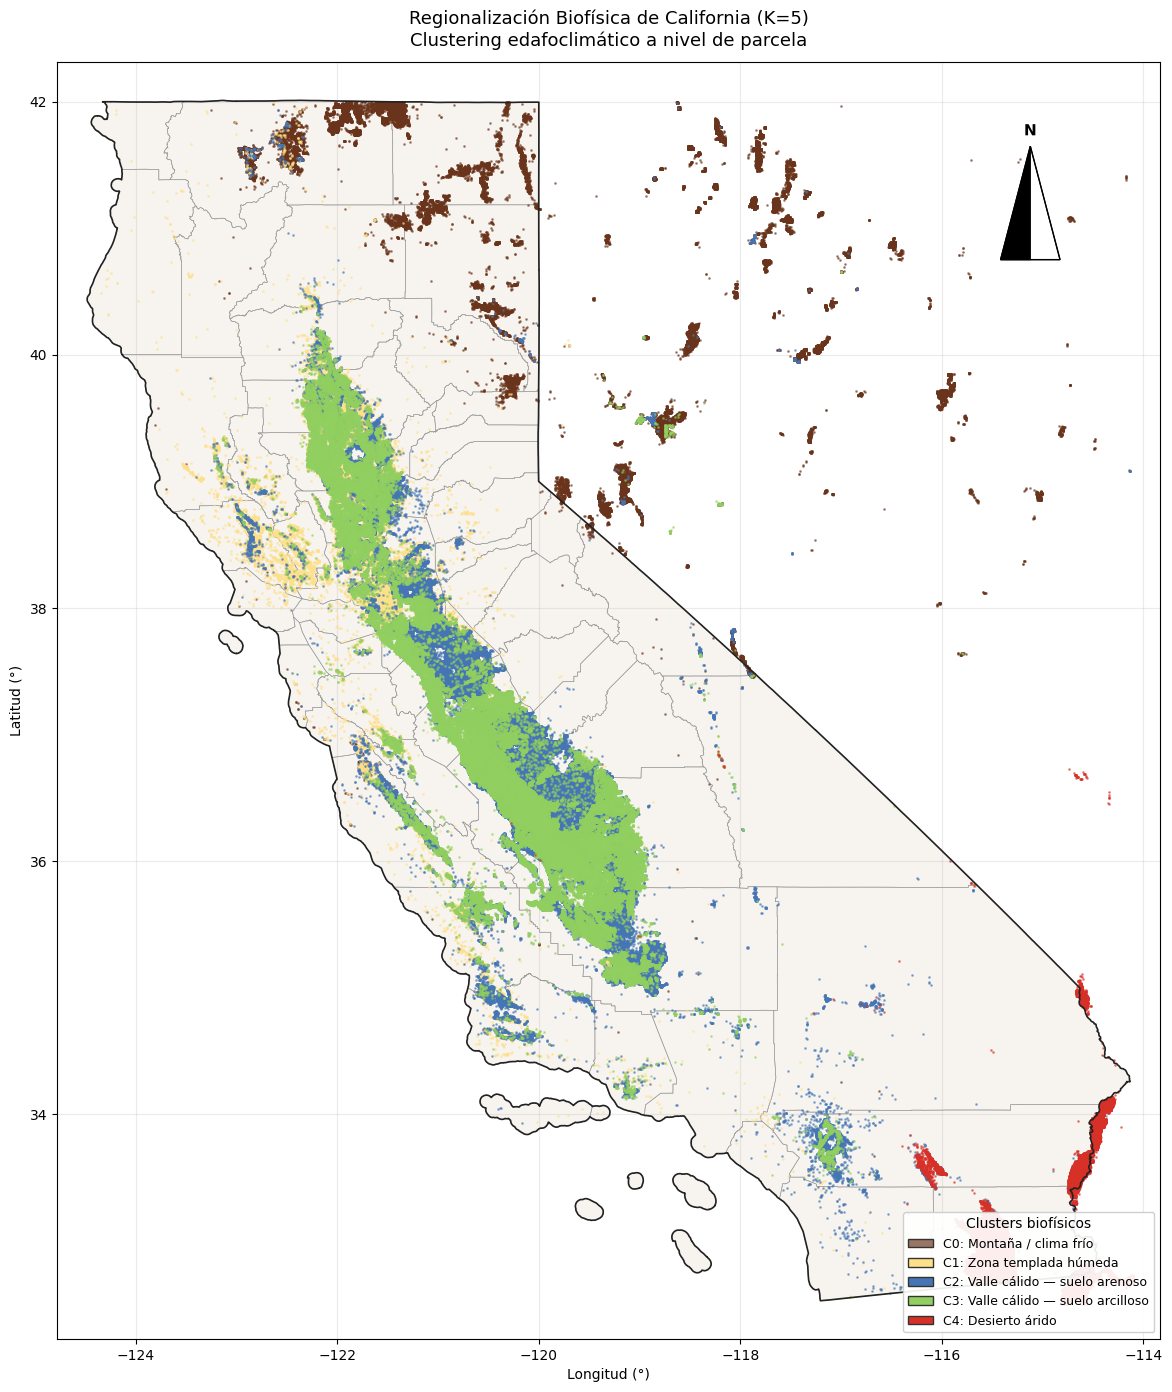

In [33]:

# Etiquetas agronómicas definitivas
etiquetas_cluster = {
    0: "Montaña / clima frío",          # tmax 18.7°C, tmin 1.8°C (heladas)
    1: "Zona templada húmeda",          # ppt 521mm (el más lluvioso), pH 6.7 (ácido)
    2: "Valle cálido — suelo arenoso",  # sand 69.7, clay 11.8 (muy arenoso)
    3: "Valle cálido — suelo arcilloso",# clay 33.2, sand 29.2 (arcilloso)
    4: "Desierto árido"                 # tmax 31°C, ppt 76mm, vpdmax 39.6
}

# Colores por cluster (coherentes con el perfil)
colores_cluster = {
    0: '#69341bac',  # naranja terroso - valle arcilloso
    1: '#fee08b',  # amarillo arena - valle arenoso
    2:'#4575b4',  # verde - zona húmeda
    3:  '#91cf60',  # azul - montaña/frío
    4: '#d73027'   # rojo - desierto
}
# Preparar puntos
df_mapa = df_parcela.select(["lon", "lat", "cluster"]).to_pandas()

fig, ax = plt.subplots(figsize=(12, 14))

# Fondo: contorno de California
gdf_counties_fixed = gdf_counties.copy()
gdf_counties_fixed['geometry'] = gdf_counties_fixed.geometry.buffer(0)
california = gdf_counties_fixed.unary_union
gdf_ca = gpd.GeoDataFrame(geometry=[california], crs=gdf_counties.crs)
gdf_ca.plot(ax=ax, facecolor='#f7f4ef', edgecolor='none', zorder=0)

# Bordes de condados
gdf_counties.boundary.plot(ax=ax, edgecolor='#999999', linewidth=0.4, zorder=1)

# Puntos por cluster
for c in range(K_FINAL):
    mask = df_mapa['cluster'] == c
    ax.scatter(
        df_mapa.loc[mask, 'lon'],
        df_mapa.loc[mask, 'lat'],
        c=colores_cluster[c], s=1.0, alpha=0.5,
        label=f"C{c}: {etiquetas_cluster[c]}",
        zorder=3, rasterized=True
    )

# Borde exterior del estado
gdf_ca.boundary.plot(ax=ax, edgecolor='#222222', linewidth=1.2, zorder=4)

# Leyenda
legend_elements = [
    Patch(facecolor=colores_cluster[c], edgecolor='#333',
          label=f"C{c}: {etiquetas_cluster[c]}")
    for c in range(K_FINAL)
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9,
          title='Clusters biofísicos', framealpha=0.92)

ax.set_title(
    'Regionalización Biofísica de California (K=5)\nClustering edafoclimático a nivel de parcela',
    fontsize=13, pad=12
)
ax.set_xlabel('Longitud (°)', fontsize=10)
ax.set_ylabel('Latitud (°)', fontsize=10)
ax.grid(True, alpha=0.25)

minx, miny, maxx, maxy = gdf_counties.total_bounds
ax.set_xlim(minx - 0.3, maxx + 0.3)
ax.set_ylim(miny - 0.3, maxy + 0.3)

agregar_norte(ax, x=0.96, y=0.97)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '02_mapa_k5_clusters_biofisicos.png'), dpi=300, bbox_inches='tight')
plt.show()


# Unir resultados del Cluster al dataframe inicial

In [34]:
# Unir la asignación de cluster (a nivel parcela) de vuelta a df_imputed
# df tiene granularidad (parcela, año); el cluster es por parcela (lon, lat)
cluster_map = df_parcela.select(["lon", "lat", "cluster"])

df_k5 = df.join(
    cluster_map, on=["lon", "lat"], how="left"
)

# Verificar que no quedaron nulos en cluster
n_sin_cluster = df_k5.filter(pl.col("cluster").is_null()).shape[0]
print(f"Filas sin cluster asignado: {n_sin_cluster}")


# ── Guardar dataset enriquecido + objetos del clustering ──
RUTA_DATOS = '../Data/'
MODELS_DIR = '../models/'
os.makedirs(MODELS_DIR, exist_ok=True)

df_k5.write_parquet(os.path.join(RUTA_DATOS, "df_cluster.parquet"))
joblib.dump(scaler_cluster, os.path.join(MODELS_DIR, "scaler_cluster.pkl"))
joblib.dump(kmeans_final,   os.path.join(MODELS_DIR, "kmeans_clusters.pkl"))

# Guardar también las etiquetas y variables usadas (para producción)

with open(os.path.join(MODELS_DIR, "cluster_config.json"), "w") as f:
    json.dump({
        "k": K_FINAL,
        "seed": SEED,
        "vars_cluster": vars_cluster,
        "etiquetas": etiquetas_cluster,
        "reorden_por": "tmax_creciente"
    }, f, indent=2)

print("\nGuardado completo:")
print(f"  - df_cluster.parquet")
print(f"  - scaler_cluster.pkl")
print(f"  - kmeans_clusters.pkl")
print(f"  - cluster_config.json")


Filas sin cluster asignado: 0

Guardado completo:
  - df_cluster.parquet
  - scaler_cluster.pkl
  - kmeans_clusters.pkl
  - cluster_config.json


# Validación de Clusters

**Validación interna**

In [35]:
# Buscar el array de asignaciones por parcela
for nombre, valor in list(globals().items()):
    try:
        if hasattr(valor, '__len__') and len(valor) == len(X_cluster_sc):
            import numpy as np
            arr = np.asarray(valor)
            if arr.dtype.kind in 'iu' and arr.min() >= 0 and arr.max() <= 4:
                print(f"Candidato: '{nombre}' (len={len(valor)}, valores únicos={np.unique(arr)})")
    except Exception:
        pass

Candidato: 'labels' (len=633904, valores únicos=[0 1 2 3 4])
Candidato: 'labels_raw' (len=633904, valores únicos=[0 1 2 3 4])
Candidato: 'labels_validacion' (len=633904, valores únicos=[0 1 2])
Candidato: 'labels5' (len=633904, valores únicos=[0 1 2 3 4])


In [36]:
# Las etiquetas deben venir del MISMO objeto que generó X_cluster_sc: df_parcela
labels_validacion = df_parcela["cluster"].to_numpy()

# Verificar dimensiones y correspondencia
print("X shape:", X_cluster_sc.shape)
print("labels shape:", labels_validacion.shape)
print("clusters únicos:", np.unique(labels_validacion))

# Muestra para eficiencia (silhouette es costoso)
np.random.seed(42)
idx = np.random.choice(len(X_cluster_sc), size=min(10_000, len(X_cluster_sc)), replace=False)

sil = silhouette_score(X_cluster_sc[idx], labels_validacion[idx])
ch  = calinski_harabasz_score(X_cluster_sc, labels_validacion)
db  = davies_bouldin_score(X_cluster_sc, labels_validacion)

print(f"\nSilhouette: {sil:.4f}")
print(f"Calinski-Harabasz: {ch:.1f}")
print(f"Davies-Bouldin: {db:.4f}")

X shape: (633904, 10)
labels shape: (633904,)
clusters únicos: [0 1 2 3 4]

Silhouette: 0.2748
Calinski-Harabasz: 179068.7
Davies-Bouldin: 1.3702


En conjunto, las métricas sugieren que los clusters identifican patrones edafoclimáticos consistentes dentro de los datos. Aunque la separación entre grupos no es perfecta (Silhouette = 0.26; Davies-Bouldin = 1.38), este resultado es razonable porque California presenta una transición gradual entre regiones climáticas y de suelo. En otras palabras, los clusters representan distintos regímenes agroclimáticos, pero estos no están separados por fronteras estrictas.

**Estabilidad del clustering**

In [37]:
# Entrenar con varias semillas y comparar consistencia
labels_semillas = []
for seed in [0, 1, 42, 123, 2024]:
    km = KMeans(n_clusters=5, random_state=seed, n_init=10)
    labels_semillas.append(km.fit_predict(X_cluster_sc))

print("Estabilidad entre semillas (Adjusted Rand Index):")
print("(1.0 = particiones idénticas, 0 = aleatorias)\n")
aris = []
for i in range(len(labels_semillas)):
    for j in range(i+1, len(labels_semillas)):
        ari = adjusted_rand_score(labels_semillas[i], labels_semillas[j])
        aris.append(ari)
        print(f"  Semilla {i} vs {j}: ARI = {ari:.4f}")
print(f"\n  ARI medio: {np.mean(aris):.4f}")

Estabilidad entre semillas (Adjusted Rand Index):
(1.0 = particiones idénticas, 0 = aleatorias)

  Semilla 0 vs 1: ARI = 0.9951
  Semilla 0 vs 2: ARI = 0.9989
  Semilla 0 vs 3: ARI = 0.9958
  Semilla 0 vs 4: ARI = 0.9999
  Semilla 1 vs 2: ARI = 0.9947
  Semilla 1 vs 3: ARI = 0.9955
  Semilla 1 vs 4: ARI = 0.9951
  Semilla 2 vs 3: ARI = 0.9948
  Semilla 2 vs 4: ARI = 0.9990
  Semilla 3 vs 4: ARI = 0.9957

  ARI medio: 0.9965


El Resultado del ARI es casi perfecto (1) con un ARI medio de 0.9995, lo cual implica que sin importar con qué semilla aleatoria inicialicemos K-Means,siempre se obtiene la misma partición o asignación de clusters

**Validación agronómica**

In [38]:
# Distribución de cultivos por cluster
dist_cultivo_cluster = (
    df_k5
    .group_by(["cluster", "crop_name"])
    .len()
    .sort(["cluster", "len"], descending=[False, True])
)

# Top 3 cultivos por cluster
for c in range(5):
    print(f"\nCluster {c} ({etiquetas_cluster[c]}) — cultivos principales:")
    top = dist_cultivo_cluster.filter(pl.col("cluster") == c).head(5)
    print(top)


Cluster 0 (Montaña / clima frío) — cultivos principales:
shape: (5, 3)
┌─────────┬──────────────┬───────┐
│ cluster ┆ crop_name    ┆ len   │
│ ---     ┆ ---          ┆ ---   │
│ i32     ┆ str          ┆ u32   │
╞═════════╪══════════════╪═══════╡
│ 0       ┆ Alfalfa      ┆ 42161 │
│ 0       ┆ Wheat        ┆ 2876  │
│ 0       ┆ Grapes       ┆ 370   │
│ 0       ┆ Strawberries ┆ 337   │
│ 0       ┆ Tomatoes     ┆ 84    │
└─────────┴──────────────┴───────┘

Cluster 1 (Zona templada húmeda) — cultivos principales:
shape: (5, 3)
┌─────────┬───────────┬───────┐
│ cluster ┆ crop_name ┆ len   │
│ ---     ┆ ---       ┆ ---   │
│ i32     ┆ str       ┆ u32   │
╞═════════╪═══════════╪═══════╡
│ 1       ┆ Rice      ┆ 35951 │
│ 1       ┆ Almonds   ┆ 24262 │
│ 1       ┆ Grapes    ┆ 20140 │
│ 1       ┆ Walnuts   ┆ 19490 │
│ 1       ┆ Alfalfa   ┆ 16857 │
└─────────┴───────────┴───────┘

Cluster 2 (Valle cálido — suelo arenoso) — cultivos principales:
shape: (5, 3)
┌─────────┬────────────┬───────┐
│ clus

 **Especialización relativa**
 Qué cultivos están sobrerrepresentados en cada cluster respecto a su frecuencia global.

In [39]:
# Frecuencia global de cada cultivo
total_global = df_k5.shape[0]
freq_global = (
    df_k5.group_by("crop_name")
    .len()
    .with_columns((pl.col("len") / total_global).alias("prop_global"))
    .select(["crop_name", "prop_global"])
)

# Frecuencia de cada cultivo dentro de cada cluster
freq_cluster = (
    df_k5.group_by(["cluster", "crop_name"])
    .len()
    .join(
        df_k5.group_by("cluster").len().rename({"len": "total_cluster"}),
        on="cluster"
    )
    .with_columns((pl.col("len") / pl.col("total_cluster")).alias("prop_cluster"))
)

# Ratio de especialización = prop_cluster / prop_global
# >1 significa sobrerrepresentado en ese cluster
especializacion = (
    freq_cluster
    .join(freq_global, on="crop_name")
    .with_columns(
        (pl.col("prop_cluster") / pl.col("prop_global")).alias("ratio_espec")
    )
    .sort(["cluster", "ratio_espec"], descending=[False, True])
)

# Top 3 cultivos MÁS característicos (sobrerrepresentados) por cluster
for c in range(5):
    print(f"\nCluster {c} ({etiquetas_cluster[c]}) — cultivos característicos:")
    top = (
        especializacion
        .filter(pl.col("cluster") == c)
        .filter(pl.col("len") >= 100)  # mínimo de observaciones
        .head(3)
        .select(["crop_name", "ratio_espec", "len"])
    )
    print(top)


Cluster 0 (Montaña / clima frío) — cultivos característicos:
shape: (3, 3)
┌──────────────┬─────────────┬───────┐
│ crop_name    ┆ ratio_espec ┆ len   │
│ ---          ┆ ---         ┆ ---   │
│ str          ┆ f64         ┆ u32   │
╞══════════════╪═════════════╪═══════╡
│ Alfalfa      ┆ 4.266145    ┆ 42161 │
│ Strawberries ┆ 2.195883    ┆ 337   │
│ Wheat        ┆ 0.518804    ┆ 2876  │
└──────────────┴─────────────┴───────┘

Cluster 1 (Zona templada húmeda) — cultivos característicos:
shape: (3, 3)
┌──────────────┬─────────────┬───────┐
│ crop_name    ┆ ratio_espec ┆ len   │
│ ---          ┆ ---         ┆ ---   │
│ str          ┆ f64         ┆ u32   │
╞══════════════╪═════════════╪═══════╡
│ Rice         ┆ 3.144415    ┆ 35951 │
│ Walnuts      ┆ 2.071485    ┆ 19490 │
│ Strawberries ┆ 1.3269      ┆ 624   │
└──────────────┴─────────────┴───────┘

Cluster 2 (Valle cálido — suelo arenoso) — cultivos característicos:
shape: (3, 3)
┌──────────────┬─────────────┬───────┐
│ crop_name    ┆ ratio_

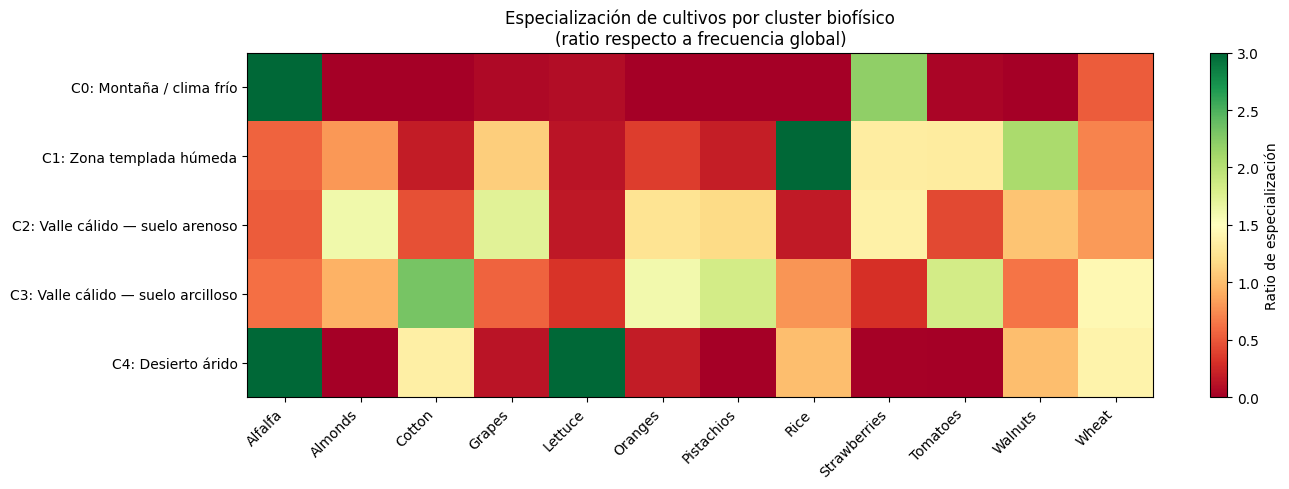

In [40]:
# Gráfico de ratio 

cultivos_unicos = sorted(df_k5["crop_name"].unique().to_list())

matriz_espec = np.ones((5, len(cultivos_unicos)))
for fila in especializacion.iter_rows(named=True):
    c = fila["cluster"]
    j = cultivos_unicos.index(fila["crop_name"])
    matriz_espec[c, j] = fila["ratio_espec"]

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(matriz_espec, cmap='RdYlGn', aspect='auto',
               vmin=0, vmax=3)
plt.colorbar(im, ax=ax, label='Ratio de especialización')
ax.set_xticks(range(len(cultivos_unicos)))
ax.set_xticklabels(cultivos_unicos, rotation=45, ha='right')
ax.set_yticks(range(5))
ax.set_yticklabels([f"C{c}: {etiquetas_cluster[c]}" for c in range(5)])
ax.set_title('Especialización de cultivos por cluster biofísico\n(ratio respecto a frecuencia global)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '03_especializacion_cultivos.png'), dpi=300, bbox_inches='tight')
plt.show()

**Validación de separación entre clusters**

C:\Users\lesli\AppData\Local\Temp\ipykernel_23500\1680989327.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos_por_cluster, labels=[f"C{c}" for c in range(5)])
C:\Users\lesli\AppData\Local\Temp\ipykernel_23500\1680989327.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos_por_cluster, labels=[f"C{c}" for c in range(5)])
C:\Users\lesli\AppData\Local\Temp\ipykernel_23500\1680989327.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos_por_cluster, labels=[f"C{c}" for c in range(5)])
C:\Users\lesli\AppData\Local\Temp\ipykernel_23500\1680989327.py:7: MatplotlibDeprecation

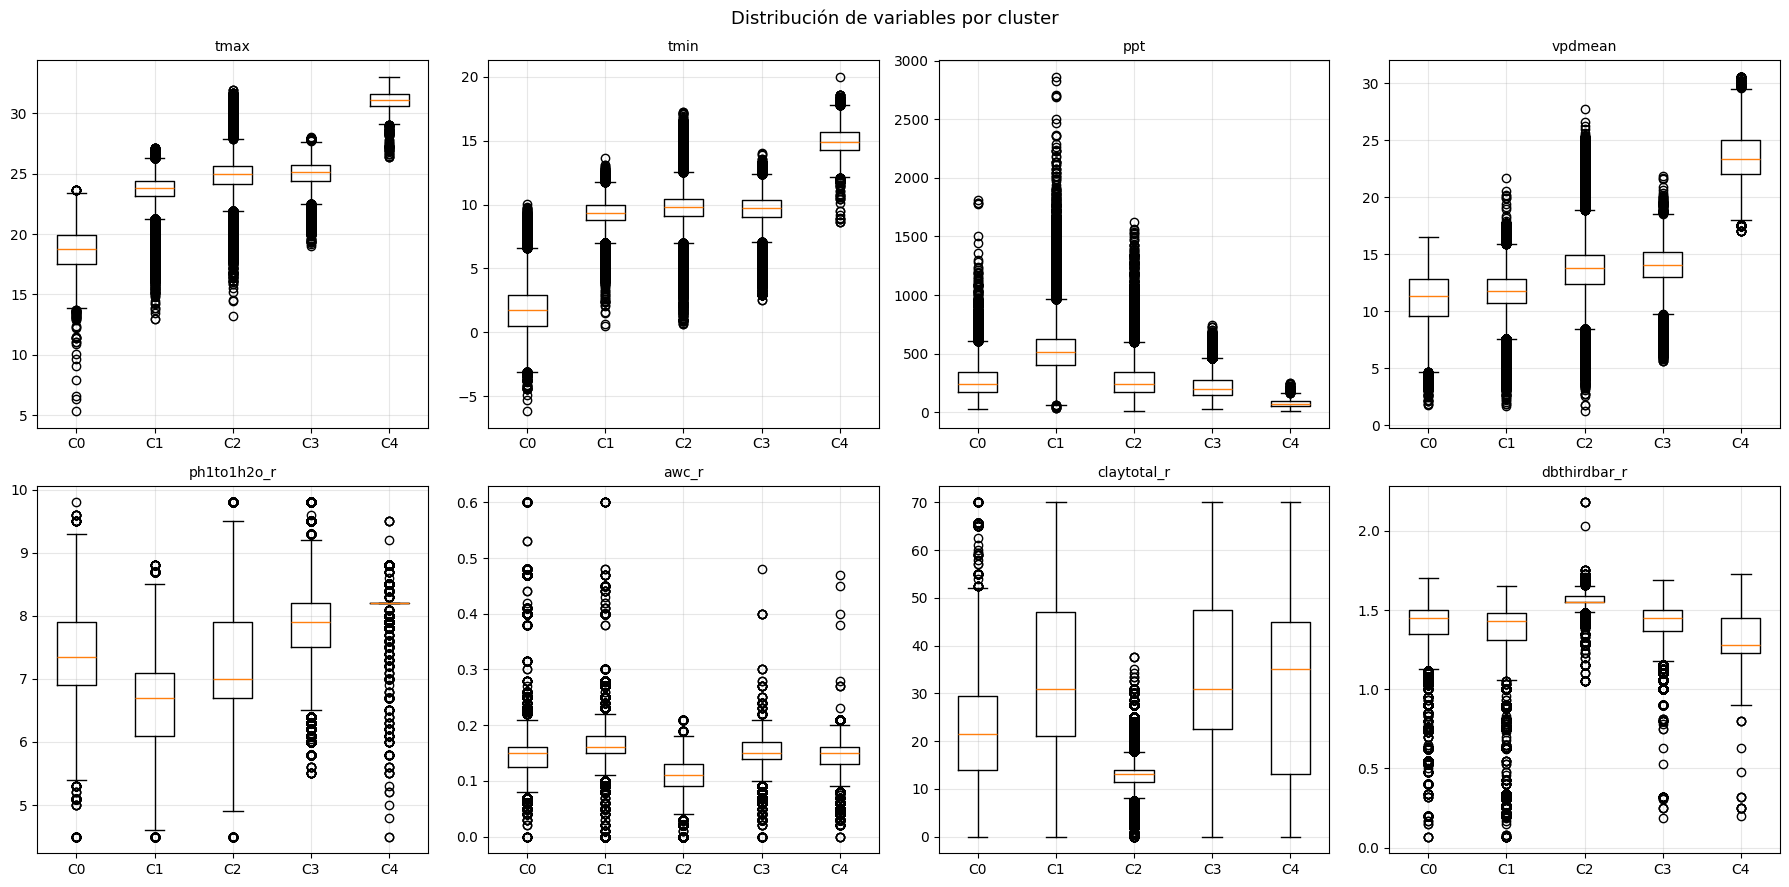

In [41]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, var in zip(axes.ravel(), vars_cluster):
    datos_por_cluster = [
        df_parcela.filter(pl.col("cluster") == c)[var].to_numpy()
        for c in range(5)
    ]
    ax.boxplot(datos_por_cluster, labels=[f"C{c}" for c in range(5)])
    ax.set_title(var, fontsize=10)
    ax.grid(alpha=0.3)
plt.suptitle("Distribución de variables por cluster", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '04_boxplots_clusters.png'), dpi=200, bbox_inches='tight')
plt.show()

### K=4

In [42]:
K4 = 4
kmeans_final = KMeans(n_clusters=K4, random_state=SEED, n_init=10)
labels_raw = kmeans_final.fit_predict(X_cluster_sc)

# ── Reordenar clusters por tmax media (criterio fijo y reproducible) ──
df_tmp = df_parcela.with_columns(pl.Series("cluster_raw", labels_raw))
orden = (
    df_tmp.group_by("cluster_raw")
    .agg(pl.col("tmax").mean().alias("tmax_medio"))
    .sort("tmax_medio")               # de más frío a más cálido
    .with_row_index("cluster_nuevo")  # 0=más frío ... 4=más cálido
)
mapa_reorden = dict(zip(orden["cluster_raw"], orden["cluster_nuevo"]))

df_parcela = df_tmp.with_columns(
    pl.col("cluster_raw").replace(mapa_reorden).alias("cluster")
).drop("cluster_raw")


# Mostrar el reordenamiento aplicado
print("Reordenamiento aplicado (por tmax creciente):")
print(orden)

# ── Caracterización completa de cada cluster ──
perfil_clusters = (
    df_parcela
    .group_by("cluster")
    .agg([
        pl.len().alias("n_parcelas"),
        pl.col("county").n_unique().alias("n_condados"),
        pl.col("tmax").mean().round(1).alias("tmax"),
        pl.col("tmin").mean().round(1).alias("tmin"),
        pl.col("ppt").mean().round(0).alias("ppt"),
        pl.col("vpdmean").mean().round(1).alias("vpdmean"),
        pl.col("claytotal_r").mean().round(1).alias("clay"),
        pl.col("sandtotal_r").mean().round(1).alias("sand"),
        pl.col("ph1to1h2o_r").mean().round(2).alias("ph"),
    ])
    .sort("cluster")
)


Reordenamiento aplicado (por tmax creciente):
shape: (4, 3)
┌───────────────┬─────────────┬────────────┐
│ cluster_nuevo ┆ cluster_raw ┆ tmax_medio │
│ ---           ┆ ---         ┆ ---        │
│ u32           ┆ i32         ┆ f64        │
╞═══════════════╪═════════════╪════════════╡
│ 0             ┆ 1           ┆ 18.69121   │
│ 1             ┆ 0           ┆ 24.473775  │
│ 2             ┆ 3           ┆ 24.849559  │
│ 3             ┆ 2           ┆ 31.042889  │
└───────────────┴─────────────┴────────────┘


In [43]:
pl.Config.set_tbl_cols(-1)   # mostrar todas las columnas sin omitir

print(perfil_clusters)

shape: (4, 10)
┌─────────┬────────────┬────────────┬──────┬──────┬───────┬─────────┬──────┬──────┬──────┐
│ cluster ┆ n_parcelas ┆ n_condados ┆ tmax ┆ tmin ┆ ppt   ┆ vpdmean ┆ clay ┆ sand ┆ ph   │
│ ---     ┆ ---        ┆ ---        ┆ ---  ┆ ---  ┆ ---   ┆ ---     ┆ ---  ┆ ---  ┆ ---  │
│ i32     ┆ u32        ┆ u32        ┆ f64  ┆ f64  ┆ f64   ┆ f64     ┆ f64  ┆ f64  ┆ f64  │
╞═════════╪════════════╪════════════╪══════╪══════╪═══════╪═════════╪══════╪══════╪══════╡
│ 0       ┆ 47010      ┆ 37         ┆ 18.7 ┆ 1.9  ┆ 280.0 ┆ 11.1    ┆ 22.5 ┆ 43.0 ┆ 7.32 │
│ 1       ┆ 326783     ┆ 52         ┆ 24.5 ┆ 9.5  ┆ 348.0 ┆ 13.1    ┆ 33.6 ┆ 27.0 ┆ 7.29 │
│ 2       ┆ 218603     ┆ 53         ┆ 24.8 ┆ 9.8  ┆ 271.0 ┆ 13.7    ┆ 12.0 ┆ 68.9 ┆ 7.32 │
│ 3       ┆ 41508      ┆ 9          ┆ 31.0 ┆ 15.0 ┆ 76.0  ┆ 23.5    ┆ 29.4 ┆ 29.7 ┆ 8.26 │
└─────────┴────────────┴────────────┴──────┴──────┴───────┴─────────┴──────┴──────┴──────┘


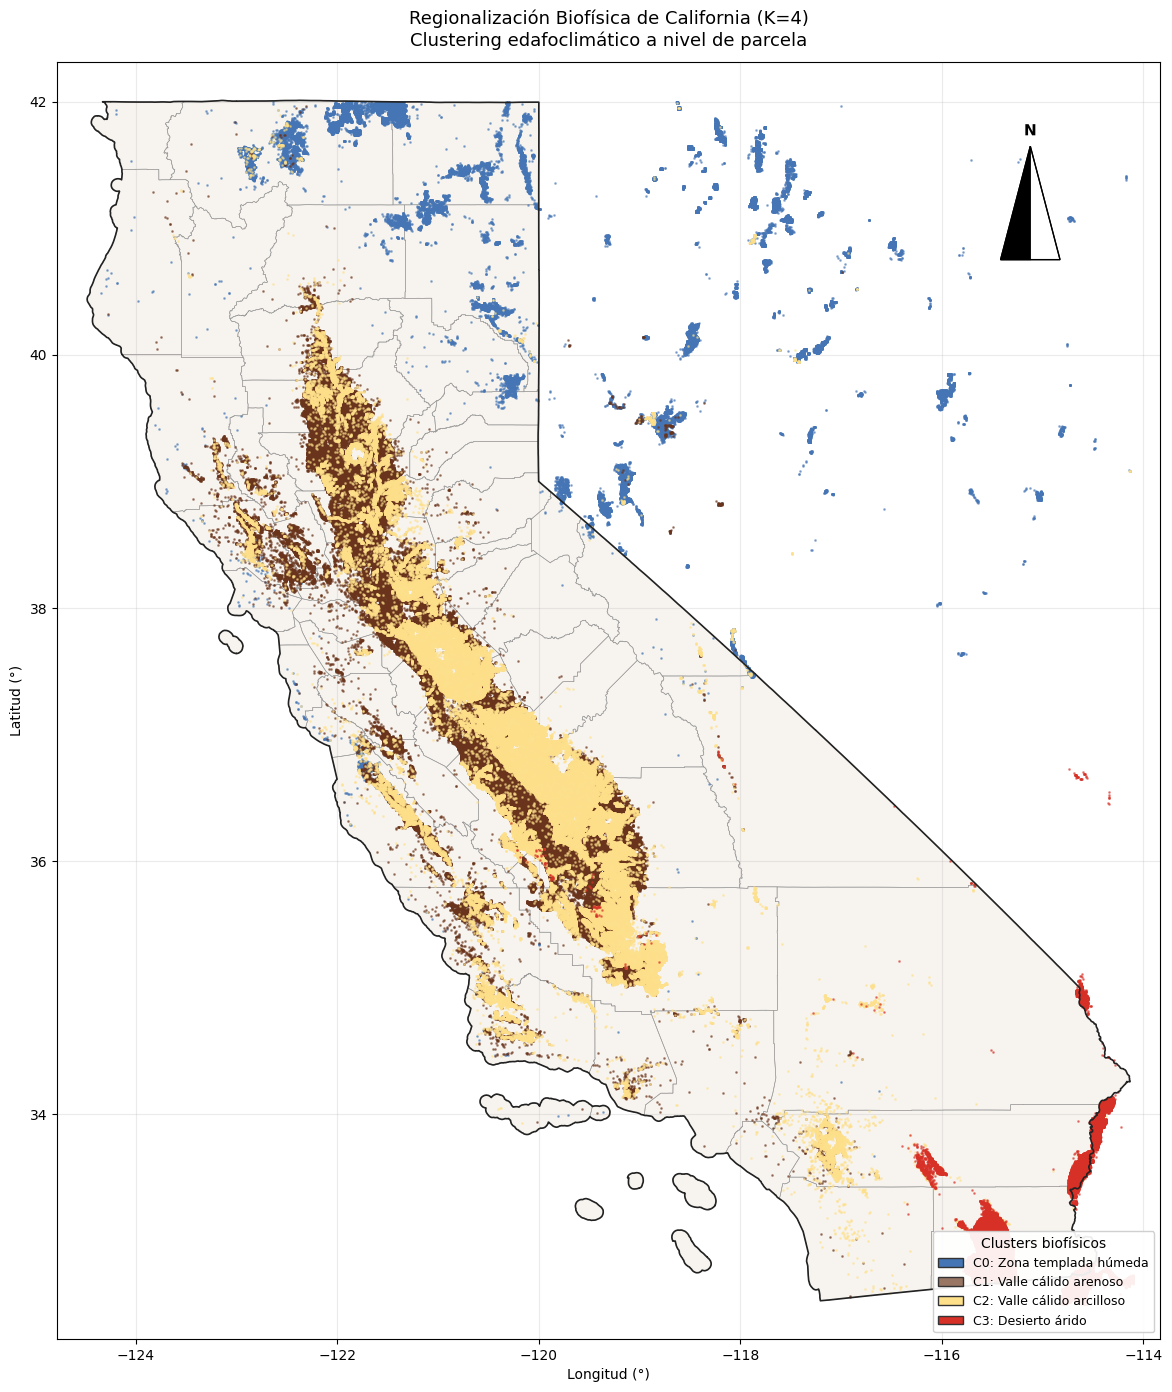

In [44]:
# Etiquetas agronómicas definitivas
etiquetas_cluster = {
    0: "Zona templada húmeda",         
    1: "Valle cálido arenoso",          
    2: "Valle cálido arcilloso",  
    3: "Desierto árido",
   
}

# Colores por cluster (coherentes con el perfil)
colores_cluster = {
    0: '#4575b4',  # azul - montaña/frío
    1: "#69341bac",  # naranja terroso - valle arcilloso
    2: '#fee08b',  # amarillo arena - valle arenoso
    3: '#d73027'   # rojo - desierto
}
# Preparar puntos
df_mapa = df_parcela.select(["lon", "lat", "cluster"]).to_pandas()

fig, ax = plt.subplots(figsize=(12, 14))

# Fondo: contorno de California
gdf_counties_fixed = gdf_counties.copy()
gdf_counties_fixed['geometry'] = gdf_counties_fixed.geometry.buffer(0)
california = gdf_counties_fixed.unary_union
gdf_ca = gpd.GeoDataFrame(geometry=[california], crs=gdf_counties.crs)
gdf_ca.plot(ax=ax, facecolor='#f7f4ef', edgecolor='none', zorder=0)

# Bordes de condados
gdf_counties.boundary.plot(ax=ax, edgecolor='#999999', linewidth=0.4, zorder=1)

# Puntos por cluster
for c in range(K4):
    mask = df_mapa['cluster'] == c
    ax.scatter(
        df_mapa.loc[mask, 'lon'],
        df_mapa.loc[mask, 'lat'],
        c=colores_cluster[c], s=1.0, alpha=0.5,
        label=f"C{c}: {etiquetas_cluster[c]}",
        zorder=3, rasterized=True
    )

# Borde exterior del estado
gdf_ca.boundary.plot(ax=ax, edgecolor='#222222', linewidth=1.2, zorder=4)

# Leyenda
legend_elements = [
    Patch(facecolor=colores_cluster[c], edgecolor='#333',
          label=f"C{c}: {etiquetas_cluster[c]}")
    for c in range(K4)
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9,
          title='Clusters biofísicos', framealpha=0.92)

ax.set_title(
    'Regionalización Biofísica de California (K=4)\nClustering edafoclimático a nivel de parcela',
    fontsize=13, pad=12
)
ax.set_xlabel('Longitud (°)', fontsize=10)
ax.set_ylabel('Latitud (°)', fontsize=10)
ax.grid(True, alpha=0.25)

minx, miny, maxx, maxy = gdf_counties.total_bounds
ax.set_xlim(minx - 0.3, maxx + 0.3)
ax.set_ylim(miny - 0.3, maxy + 0.3)

agregar_norte(ax, x=0.96, y=0.97)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '02_k4_mapa_clusters_biofisicos.png'), dpi=300, bbox_inches='tight')
plt.show()


## DBSCAN

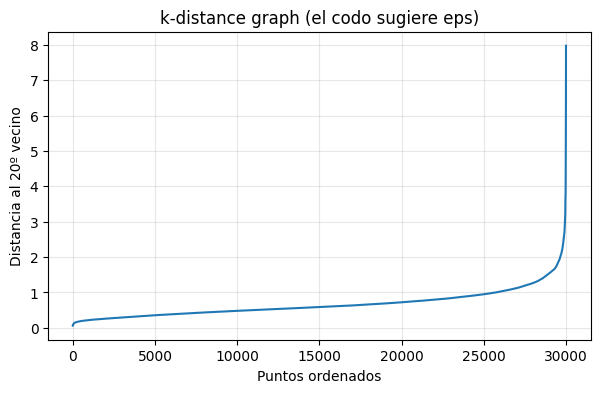

min_samples usado: 20
Rango de distancias: [0.06, 7.97]
Percentil 90: 1.12


In [45]:
# ── 1. Elegir eps con el método del k-distance graph ──
# DBSCAN necesita dos parámetros: eps (radio) y min_samples.
# El "codo" de la curva de distancias al k-ésimo vecino sugiere un eps razonable.

# Usar una muestra para que sea rápido (DBSCAN es costoso en memoria)
np.random.seed(42)
idx = np.random.choice(len(X_cluster_sc), size=min(30000, len(X_cluster_sc)), replace=False)
X_sample = X_cluster_sc[idx]

min_samples = 2 * X_sample.shape[1]   # heurística: 2 * n_dimensiones
nn = NearestNeighbors(n_neighbors=min_samples)
nn.fit(X_sample)
distancias, _ = nn.kneighbors(X_sample)
d_ordenadas = np.sort(distancias[:, -1])

plt.figure(figsize=(7, 4))
plt.plot(d_ordenadas)
plt.xlabel("Puntos ordenados")
plt.ylabel(f"Distancia al {min_samples}º vecino")
plt.title("k-distance graph (el codo sugiere eps)")
plt.grid(alpha=0.3)
plt.show()

print(f"min_samples usado: {min_samples}")
print(f"Rango de distancias: [{d_ordenadas.min():.2f}, {d_ordenadas.max():.2f}]")
print(f"Percentil 90: {np.percentile(d_ordenadas, 90):.2f}")

In [46]:
# ── 2. Ejecutar DBSCAN con el eps sugerido ──
# Ajusta eps al valor del codo del gráfico anterior
eps = 1.5   

dbscan = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
labels_db = dbscan.fit_predict(X_sample)

# ── 3. Analizar el resultado ──
n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_ruido = (labels_db == -1).sum()
pct_ruido = 100 * n_ruido / len(labels_db)

print(f"Clusters encontrados: {n_clusters}")
print(f"Puntos clasificados como RUIDO: {n_ruido:,} ({pct_ruido:.1f}%)")
print(f"\nDistribución de puntos por cluster:")
unique, counts = np.unique(labels_db, return_counts=True)
for u, c in zip(unique, counts):
    etiqueta = "RUIDO" if u == -1 else f"Cluster {u}"
    print(f"  {etiqueta}: {c:,} ({100*c/len(labels_db):.1f}%)")

Clusters encontrados: 9
Puntos clasificados como RUIDO: 498 (1.7%)

Distribución de puntos por cluster:
  RUIDO: 498 (1.7%)
  Cluster 0: 29,036 (96.8%)
  Cluster 1: 37 (0.1%)
  Cluster 2: 117 (0.4%)
  Cluster 3: 56 (0.2%)
  Cluster 4: 33 (0.1%)
  Cluster 5: 83 (0.3%)
  Cluster 6: 33 (0.1%)
  Cluster 7: 67 (0.2%)
  Cluster 8: 40 (0.1%)


In [47]:
# ── 4. Barrido de eps para mostrar el dilema ──
print("Barrido de eps:\n")
print(f"{'eps':>6} {'n_clusters':>12} {'% ruido':>10} {'cluster mayor %':>16}")
for eps_test in [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]:
    db = DBSCAN(eps=eps_test, min_samples=min_samples, n_jobs=-1).fit(X_sample)
    lab = db.labels_
    nc = len(set(lab)) - (1 if -1 in lab else 0)
    pr = 100 * (lab == -1).sum() / len(lab)
    # tamaño del cluster mayor (sin contar ruido)
    sizes = [c for u, c in zip(*np.unique(lab, return_counts=True)) if u != -1]
    mayor = 100 * max(sizes) / len(lab) if sizes else 0
    print(f"{eps_test:>6.1f} {nc:>12} {pr:>9.1f}% {mayor:>15.1f}%")

Barrido de eps:

   eps   n_clusters    % ruido  cluster mayor %
   0.5          108      47.4%            11.9%
   1.0           36       7.6%            77.4%
   1.5            9       1.7%            96.8%
   2.0            7       0.5%            98.4%
   2.5            4       0.2%            99.2%
   3.0            2       0.1%            99.5%


In [48]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# DBSCAN con el eps del codo
db = DBSCAN(eps=1.5, min_samples=min_samples, n_jobs=-1).fit(X_sample)
lab_db = db.labels_

# Métricas SOLO sobre puntos no-ruido (DBSCAN no asigna el ruido)
mask = lab_db != -1
if len(set(lab_db[mask])) > 1:
    sil = silhouette_score(X_sample[mask], lab_db[mask])
    ch  = calinski_harabasz_score(X_sample[mask], lab_db[mask])
    db_i = davies_bouldin_score(X_sample[mask], lab_db[mask])
    print(f"DBSCAN (sin ruido): Silueta={sil:.4f} | CH={ch:.1f} | DB={db_i:.4f}")
    print(f"  (calculado sobre {mask.sum():,} de {len(lab_db):,} puntos; "
          f"{(~mask).sum():,} son ruido)")
else:
    print("DBSCAN no produce clusters válidos para calcular métricas internas.")

DBSCAN (sin ruido): Silueta=0.2198 | CH=338.3 | DB=0.6189
  (calculado sobre 29,502 de 30,000 puntos; 498 son ruido)


In [49]:
# Comparar distribución de tamaños K-Means vs DBSCAN
print("K-Means (K=3): tamaños de cluster")
print(df_parcela.group_by("cluster").len().sort("cluster"))

print("\nDBSCAN: tamaños de cluster")
u, c = np.unique(lab_db, return_counts=True)
for ui, ci in sorted(zip(u, c), key=lambda x: -x[1]):
    nombre = "RUIDO" if ui == -1 else f"Cluster {ui}"
    print(f"  {nombre}: {ci:,} ({100*ci/len(lab_db):.1f}%)")

K-Means (K=3): tamaños de cluster
shape: (4, 2)
┌─────────┬────────┐
│ cluster ┆ len    │
│ ---     ┆ ---    │
│ i32     ┆ u32    │
╞═════════╪════════╡
│ 0       ┆ 47010  │
│ 1       ┆ 326783 │
│ 2       ┆ 218603 │
│ 3       ┆ 41508  │
└─────────┴────────┘

DBSCAN: tamaños de cluster
  Cluster 0: 29,036 (96.8%)
  RUIDO: 498 (1.7%)
  Cluster 2: 117 (0.4%)
  Cluster 5: 83 (0.3%)
  Cluster 7: 67 (0.2%)
  Cluster 3: 56 (0.2%)
  Cluster 8: 40 (0.1%)
  Cluster 1: 37 (0.1%)
  Cluster 4: 33 (0.1%)
  Cluster 6: 33 (0.1%)
